# eDNA Metabarcoding Pipeline Analysis: Lake Geneva Water
### isONclust3 Clustering Pipeline (Q15 Filter)
**Databases:** PR2 (18S) + MIDORI2 (COI)

**Project:** Genorobotics Semester Project (EPFL)  
**Dataset:** Water eDNA from Lake Geneva  
**Pipeline:** ONT metabarcoding with isONclust3 + SPOA consensus  
**Run date:** May 29, 2026

In [1]:
from scripts.notebook_utils import *
from pathlib import Path

setup_style()

BASE = latest_run("Water_eDNA_18S_COI_14_01_26")
MARKERS = ['18S', 'COI']

In [2]:
# Load taxonomy data
df_18s = pd.read_csv(BASE / 'taxonomy_summary/18S/pr2/comprehensive_taxonomy_18S.csv')
df_coi_raw = pd.read_csv(BASE / 'taxonomy_summary/COI/midori2/comprehensive_taxonomy_COI.csv')

df_18s.columns = df_18s.columns.str.lower()
df_coi_raw.columns = df_coi_raw.columns.str.lower()

prefix_18s = get_tax_prefix(df_18s)
prefix_coi = get_tax_prefix(df_coi_raw)

print_data_summary(df_18s, '18S', prefix_18s)
print_data_summary(df_coi_raw, 'COI', prefix_coi)
display(df_18s.head(3))
display(df_coi_raw.head(3))


  18S (pr2 database)  -  142 OTUs x 38 columns

Metadata columns:  ['otu_id', 'total_abundance', 'rank', 'sample_unclassified', 'ncbi_tophit', 'ncbi_identity', 'ncbi_evalue']
Sample columns:    ['sample_barcode01', 'sample_barcode02', 'sample_barcode03', 'sample_barcode04', 'sample_barcode05', 'sample_barcode06', 'sample_barcode07', 'sample_barcode08', 'sample_barcode09', 'sample_barcode10', 'sample_barcode11', 'sample_barcode12', 'sample_barcode13', 'sample_barcode14', 'sample_barcode15']
Taxonomy columns:  ['pr2_domain', 'pr2_domain_conf', 'pr2_supergroup', 'pr2_supergroup_conf', 'pr2_division', 'pr2_division_conf', 'pr2_class', 'pr2_class_conf', 'pr2_order', 'pr2_order_conf', 'pr2_family', 'pr2_family_conf', 'pr2_genus', 'pr2_genus_conf', 'pr2_species', 'pr2_species_conf']

  COI (midori2 database)  -  159 OTUs x 50 columns

Metadata columns:  ['otu_id', 'total_abundance', 'rank', 'sample_unclassified', 'ncbi_tophit', 'ncbi_identity', 'ncbi_evalue']
Sample columns:    ['sample_barc

,otu_id,total_abundance,rank,sample_barcode01,sample_barcode02,sample_barcode03,sample_barcode04,sample_barcode05,sample_barcode06,sample_barcode07,...,pr2_order_conf,pr2_family,pr2_family_conf,pr2_genus,pr2_genus_conf,pr2_species,pr2_species_conf,ncbi_tophit,ncbi_identity,ncbi_evalue
0,OTU_18S_000085,12.181204,1,0.450884,0.863064,0.866109,0.848699,0.0,0.0,0.942283,...,0.91,Pelagostrombidiidae,0.83,NaN,NaN,NaN,NaN,Uncultured ciliate clone,97.7,0.0
1,OTU_18S_000063,1.578325,2,0.539807,0.132791,0.118226,0.146274,0.0,0.0,0.051696,...,0.98,Branchiopoda,0.98,Daphnia,0.77,Daphnia_pulex,0.59,Daphnia galeata isolate,89.8,0.0
2,OTU_18S_000020,0.048544,3,0.000797,0.000638,0.003387,0.000477,0.0,0.0,0.001904,...,0.61,Cryptomonadales_X:nucl,0.60,Plagioselmis:nucl,0.54,Plagioselmis_lacustris:nucl,0.54,Uncultured freshwater eukaryote,99.7,0.0


,otu_id,total_abundance,rank,sample_barcode01,sample_barcode02,sample_barcode03,sample_barcode04,sample_barcode05,sample_barcode06,sample_barcode07,...,midori2_genus_conf,midori2_genus_taxid,midori2_genus_imputed,midori2_species,midori2_species_conf,midori2_species_taxid,midori2_species_imputed,ncbi_tophit,ncbi_identity,ncbi_evalue
0,OTU_COI_000107,0.728670,1,0.0,0.0,0.0,0.0,0.443306,0.212783,0.0,...,0.01,706309.0,False,Calliodis,0.01,NaN,False,Candidatus Pelagibacterales bacterium,94.2,0.0
1,OTU_COI_000160,0.457353,2,0.0,0.0,0.0,0.0,0.260303,0.108340,0.0,...,0.02,7191.0,False,Simulium,0.02,NaN,False,Candidatus Pelagibacterales bacterium,98.8,0.0
2,OTU_COI_000009,0.359197,3,0.0,0.0,0.0,0.0,0.080326,0.254677,0.0,...,1.00,6668.0,False,Daphnia,1.00,NaN,False,Daphnia galeata mitochondrial,98.0,0.0


## 0. Pipeline Overview & Key Changes

**Pipeline steps:**
1. Preprocessing (quality filter Q>=15, length filter)
2. Marker classification (minimap2 against reference amplicons)
2b. Primer trimming (cutadapt — validates amplicon identity)
3. Clustering (isONclust3 + SPOA consensus)
3b. Chimera removal (VSEARCH uchime_denovo with size annotations)
4. Abundance matrix generation
5. Taxonomy assignment (VSEARCH SINTAX, confidence >= 0.8)
6. BLAST validation (top OTUs vs NCBI)
7. Comprehensive summary

### Results (May 29, 2026)
| Marker | Raw Clusters | Chimeras | Clean OTUs |
|--------|:---:|:---:|:---:|
| 18S | 148 | 6 (4.1%) | **142** |
| COI | 262 | 29 (11.1%) | **195** |

- 16 samples (barcodes): 13 → 18S, 2 → COI, 1 negative control
- Total reads: 242,625 → 213,946 kept (11.8% discarded at primer step)

## Confidence Distribution Dashboard

[('pr2', ['domain', 'supergroup', 'division', 'class', 'order', 'family', 'genus', 'species']), ('midori2', ['kingdom', 'phylum', 'class', 'order', 'family', 'genus', 'species'])]


\\wsl.localhost\Ubuntu\home\ilias\Geno\Leman-eDNA-Pipeline\scripts\notebook_utils.py:242: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


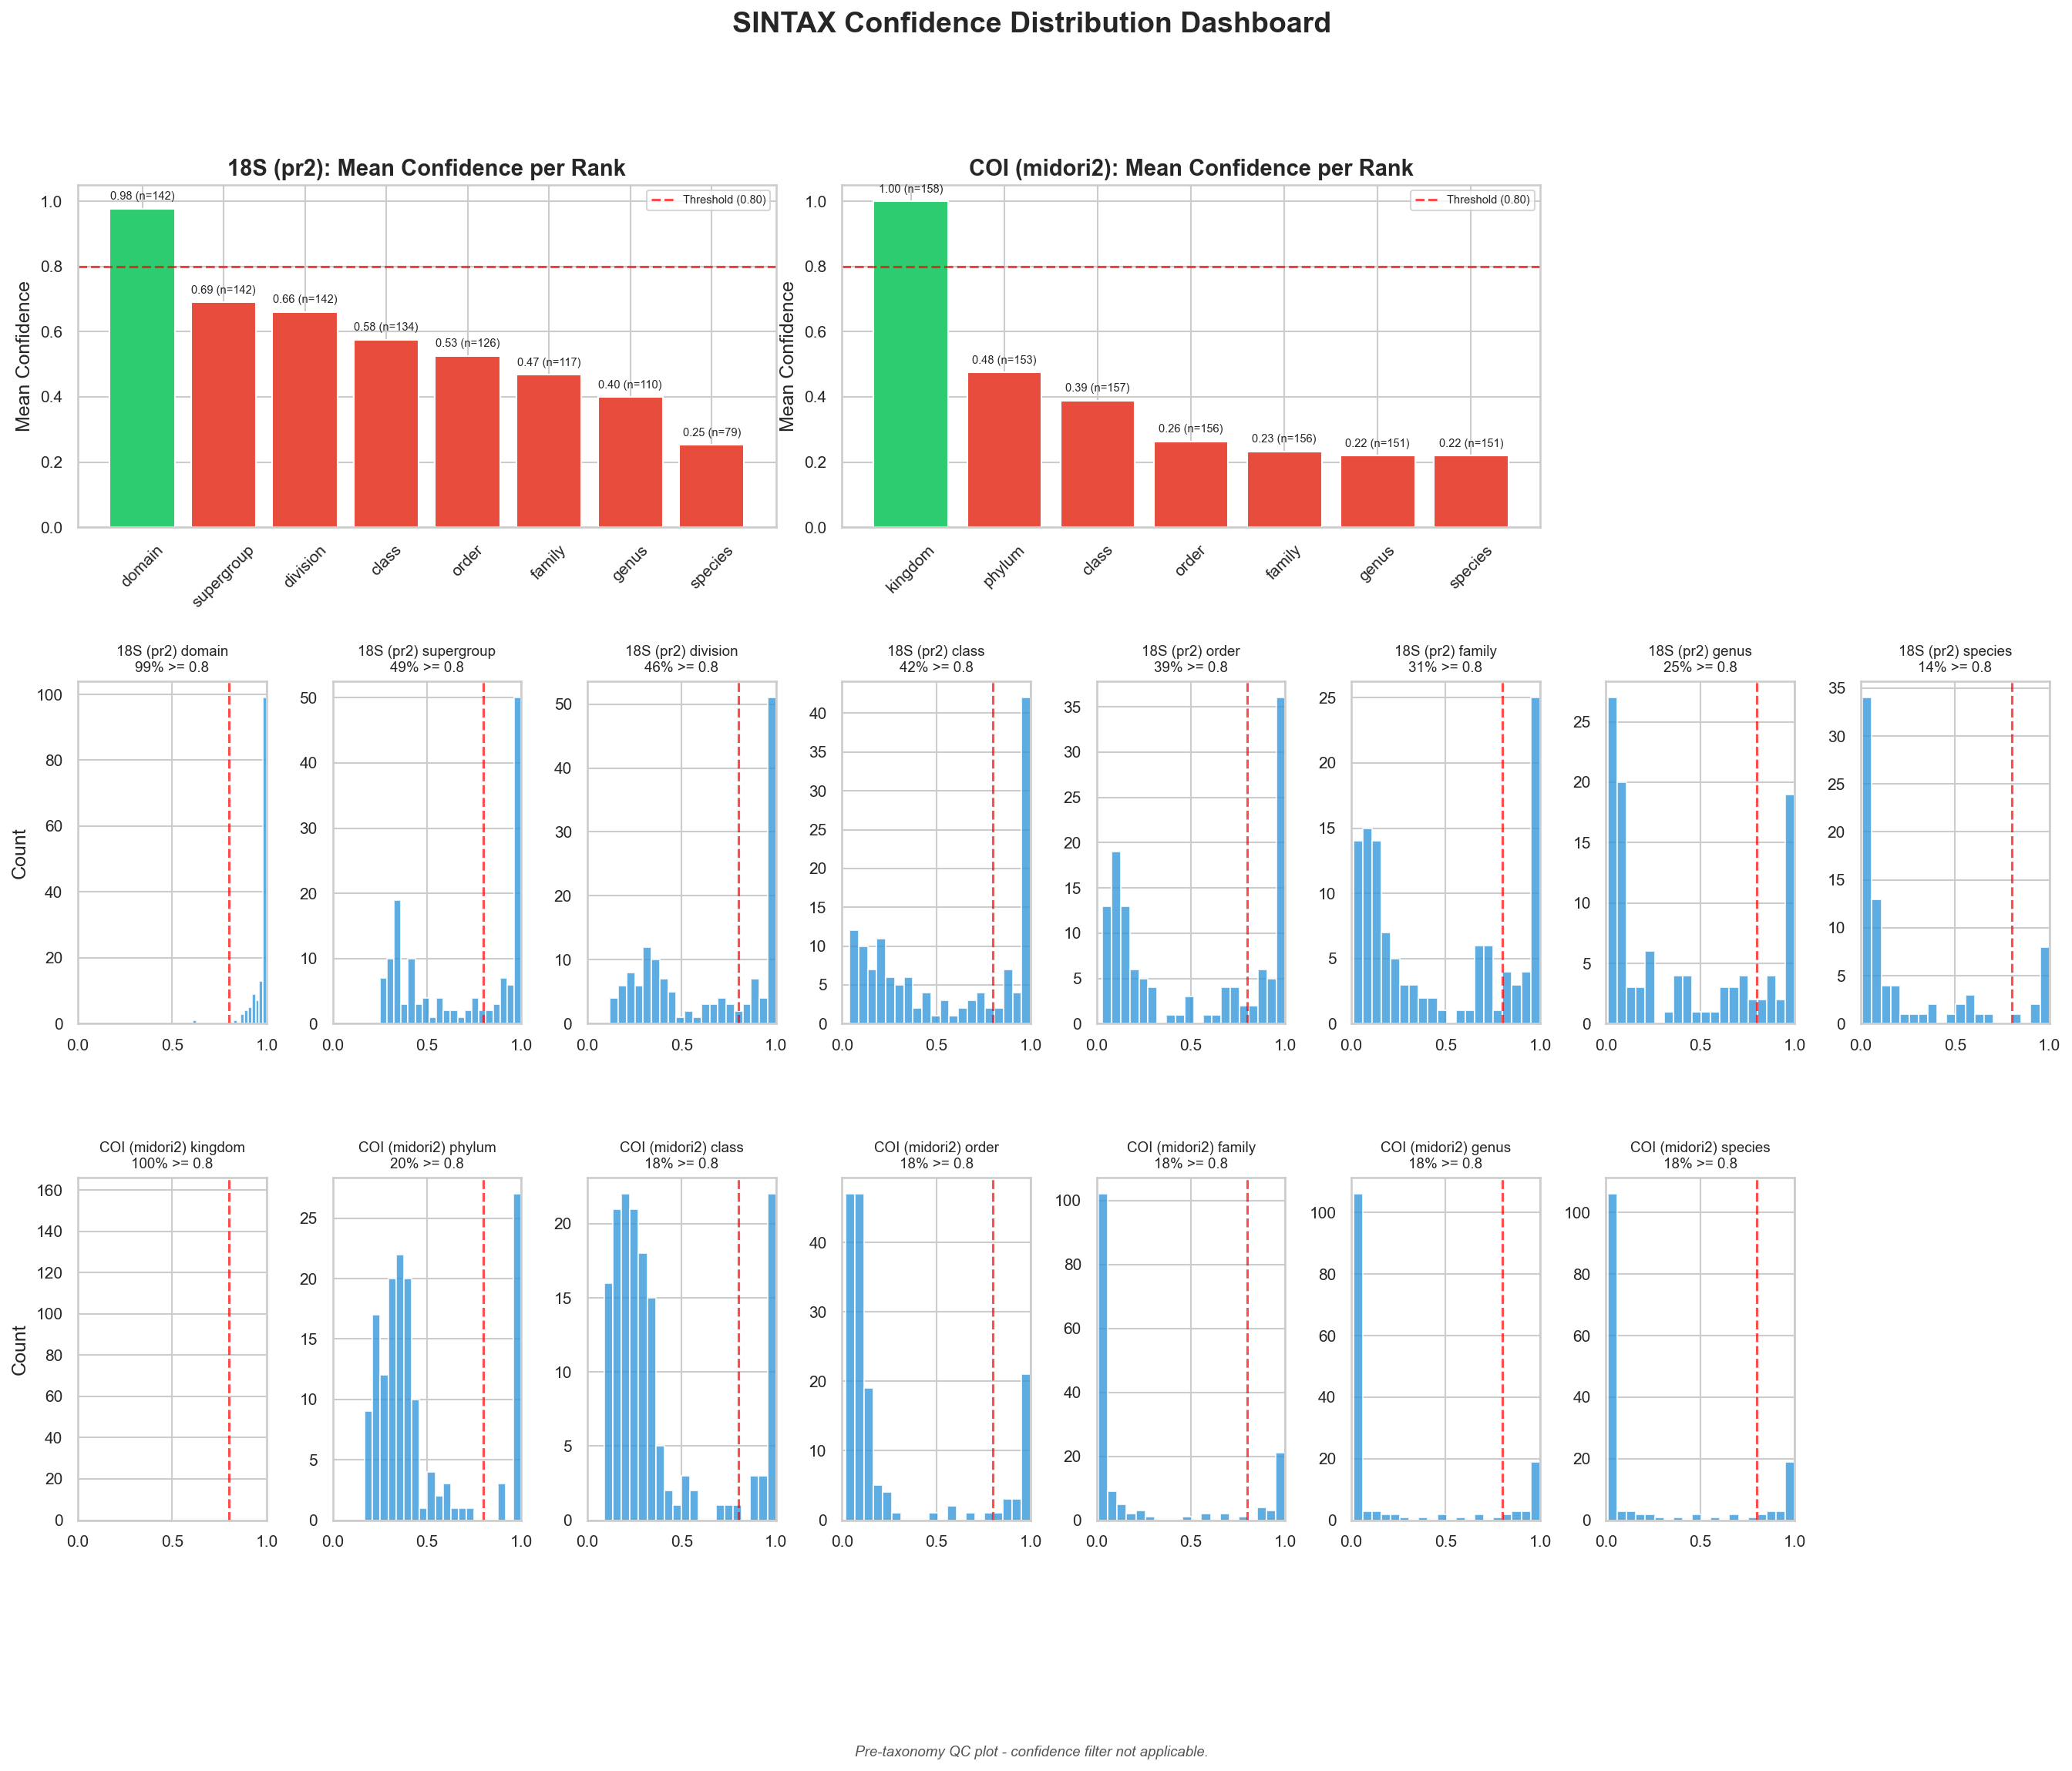

In [3]:
confidence_dashboard([
    (df_18s, prefix_18s, f'18S ({prefix_18s})'),
    (df_coi_raw, prefix_coi, f'COI ({prefix_coi})')
])

## Database Performance Dashboard
Evaluate how well the reference database classifies our OTUs:
- Assignment rate per rank (any vs confident)
- Read-weighted coverage
- Resolution depth (how far down taxonomy we can resolve)

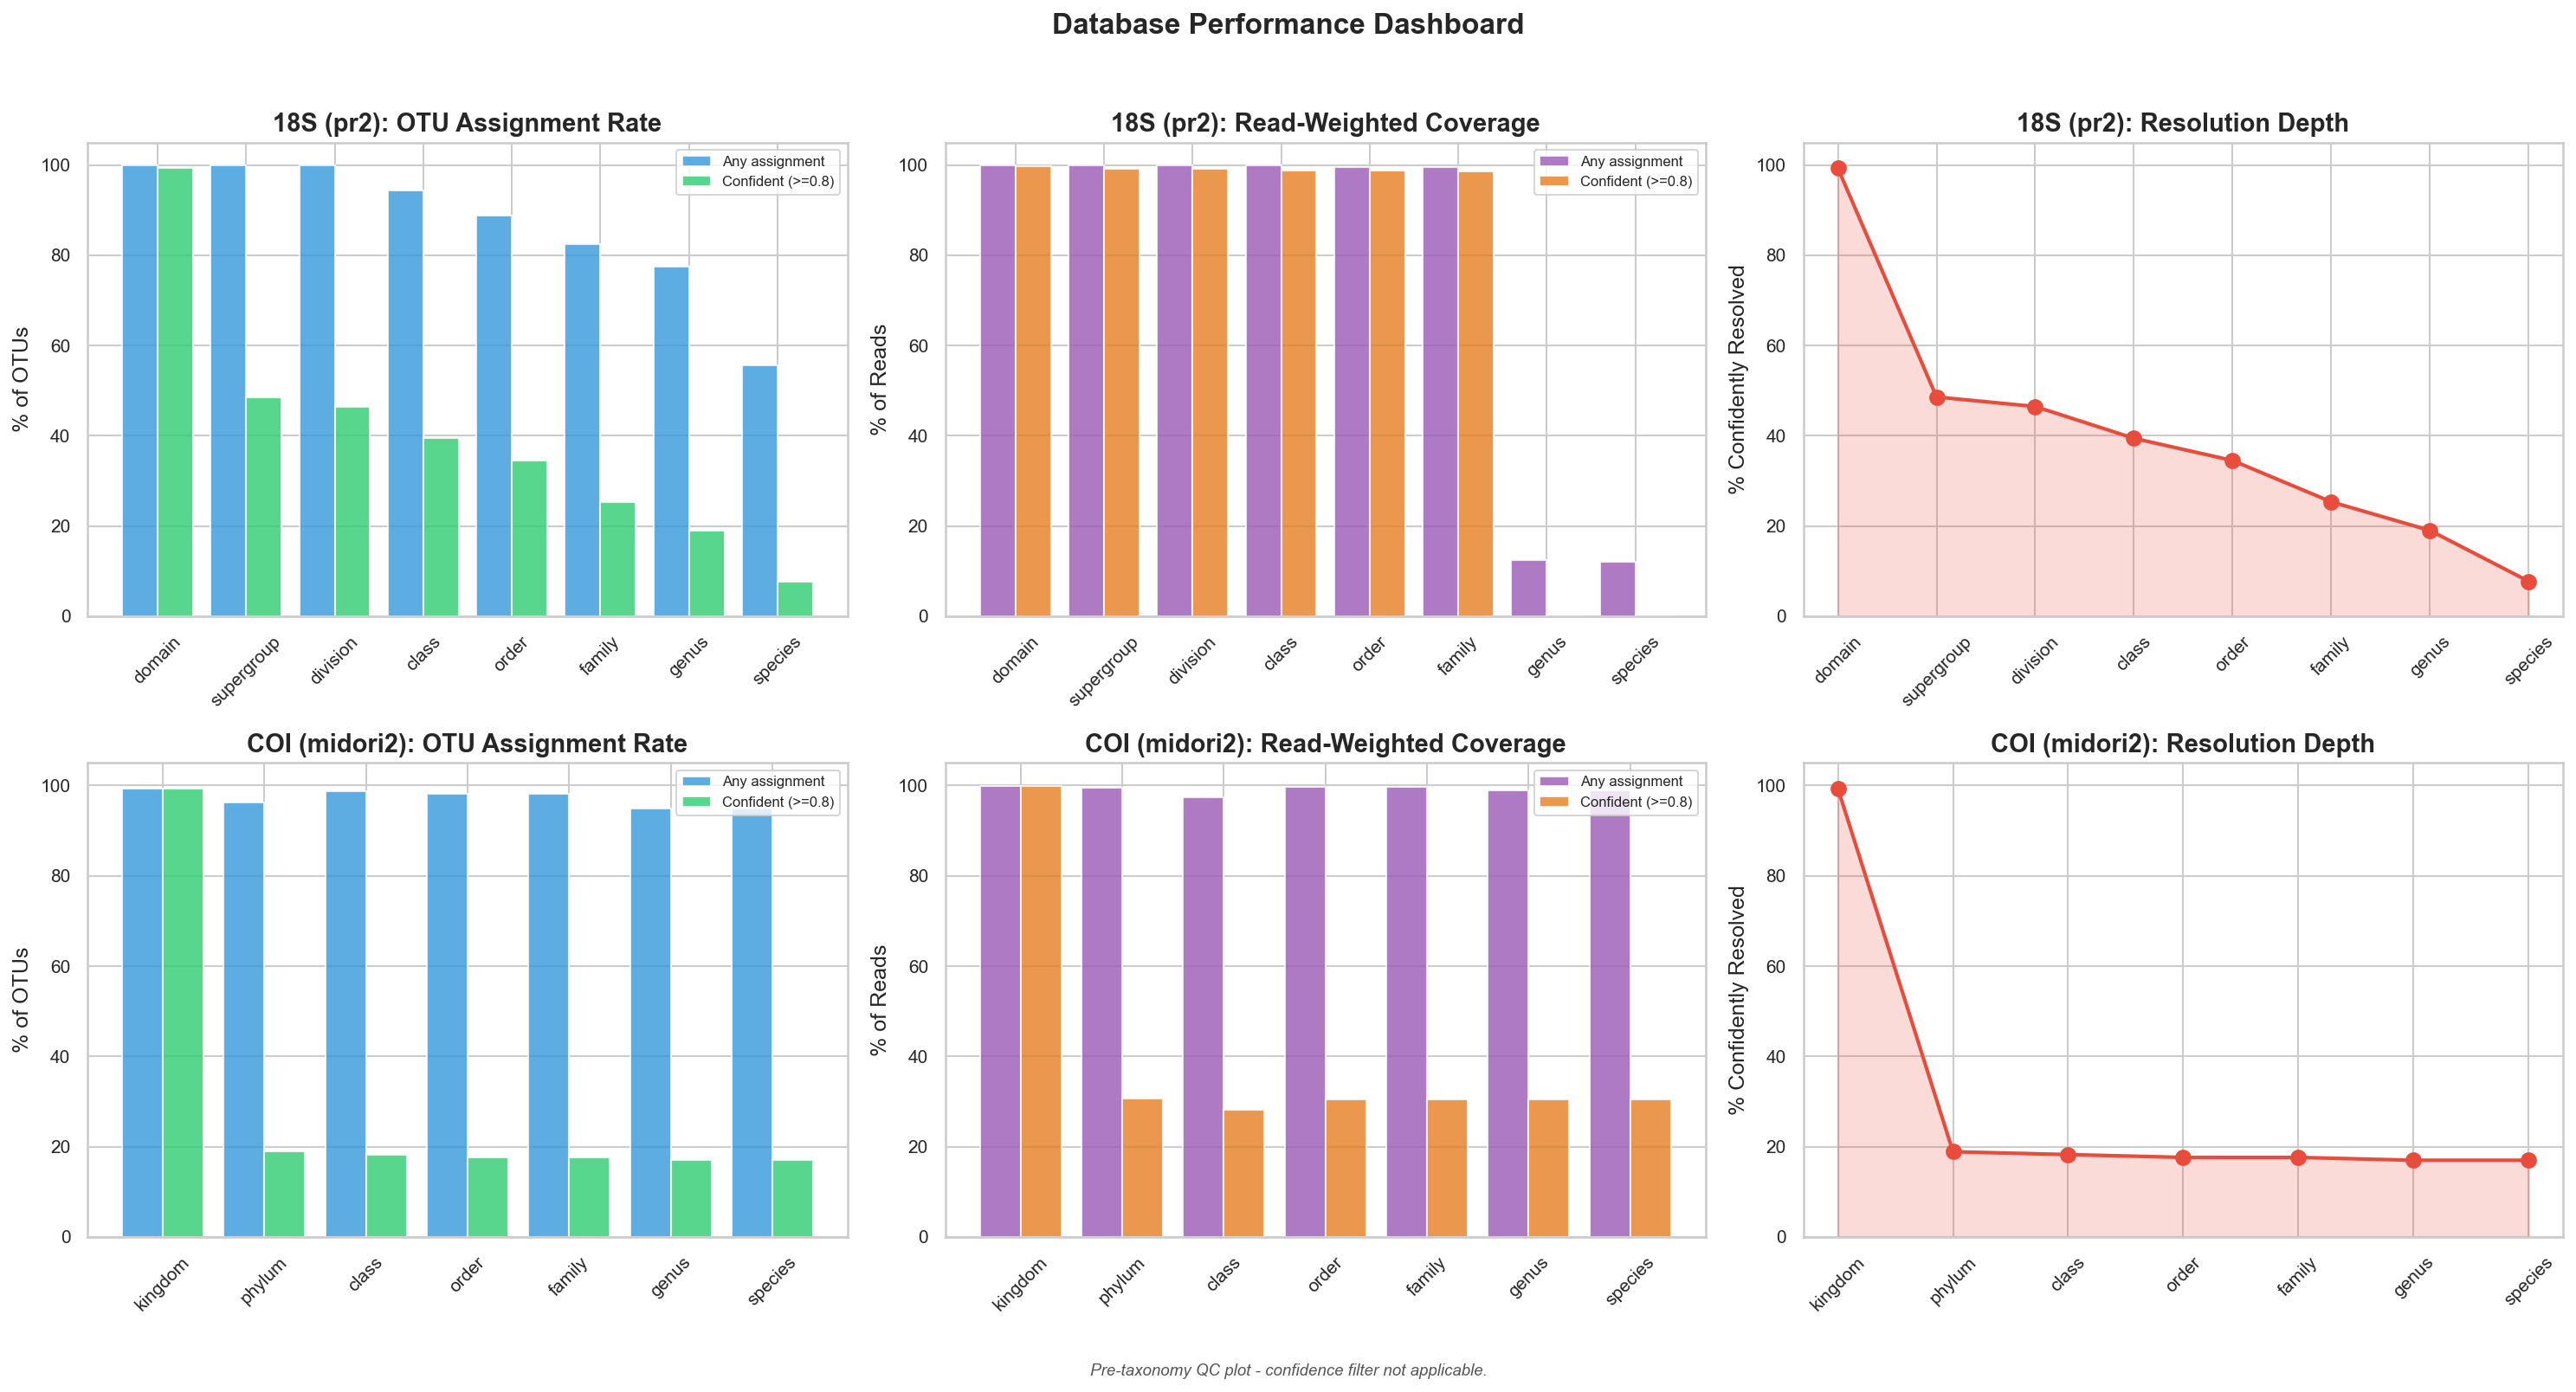

In [4]:
db_performance_dashboard([
    (df_18s, prefix_18s, f'18S ({prefix_18s})'),
    (df_coi_raw, prefix_coi, f'COI ({prefix_coi})')
])

## Raw Read Length Distributions (Pre-Clustering)
Sequence lengths before clustering — reveals expected amplicon sizes and any off-target.

✓ 18S: 204,134 reads, median=1779bp, range=15-3485bp
✓ COI: 9,812 reads, median=754bp, range=400-2218bp


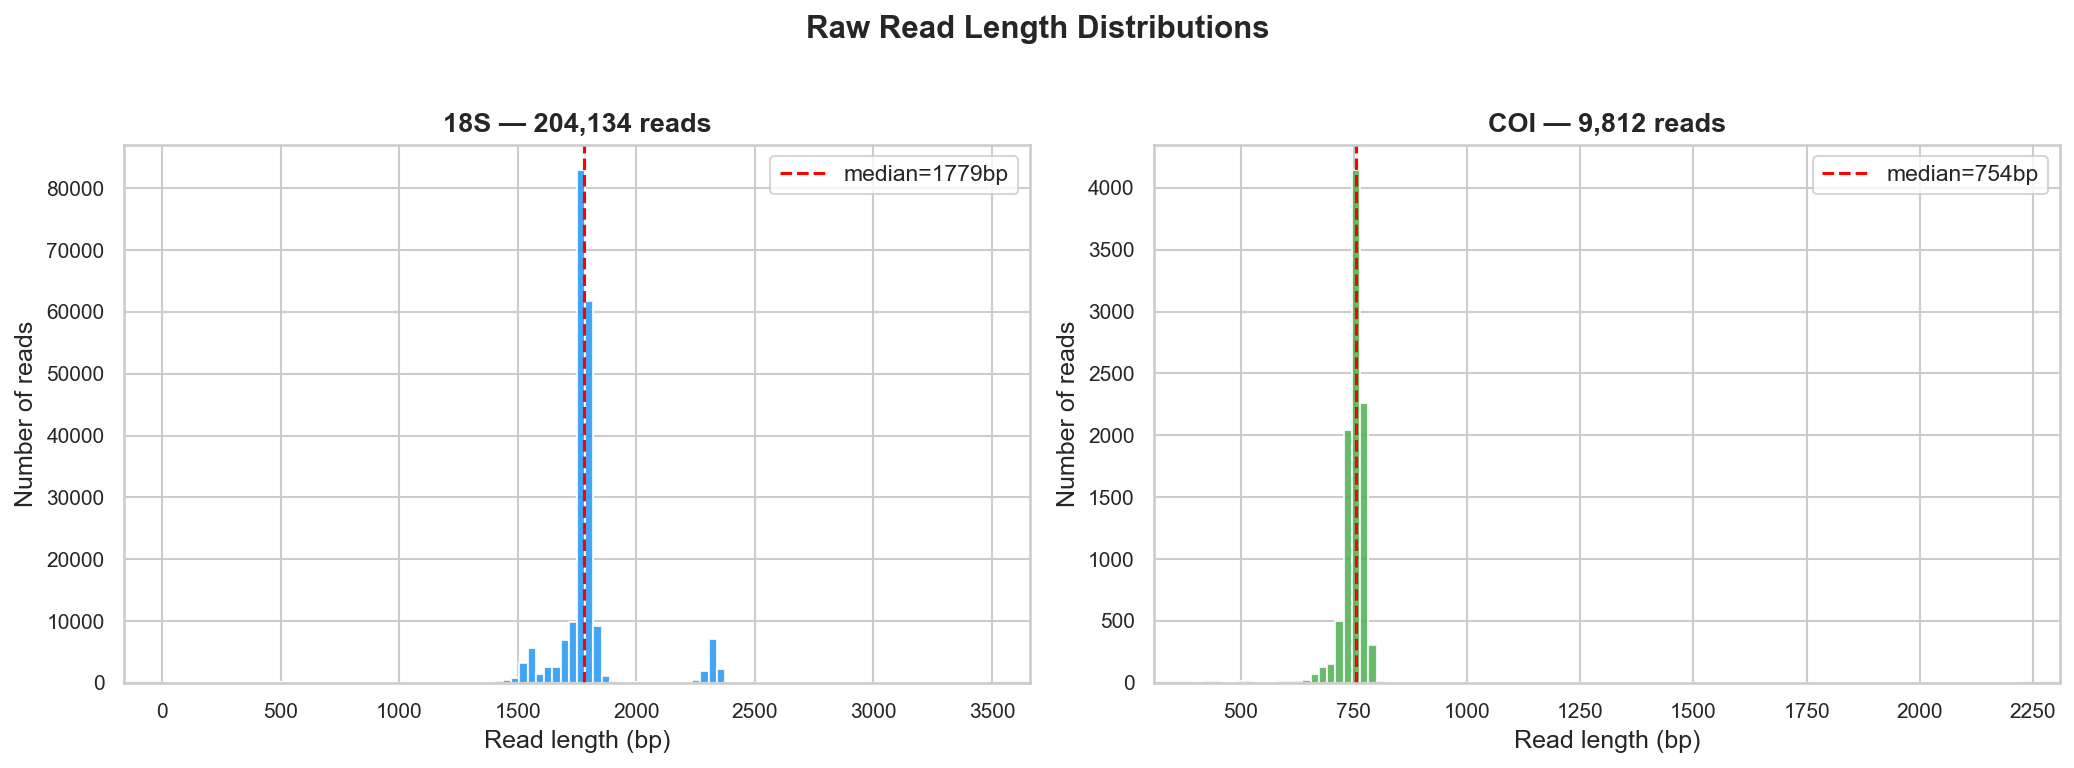

In [5]:
plot_read_lengths(BASE, MARKERS)

## Consensus OTU Sequence Length Distributions
Length of final consensus OTUs — should cluster around expected amplicon size.

✓ 18S: 142 OTUs, median=1970bp, range=396-3676bp
✓ COI: 158 OTUs, median=804bp, range=588-2168bp


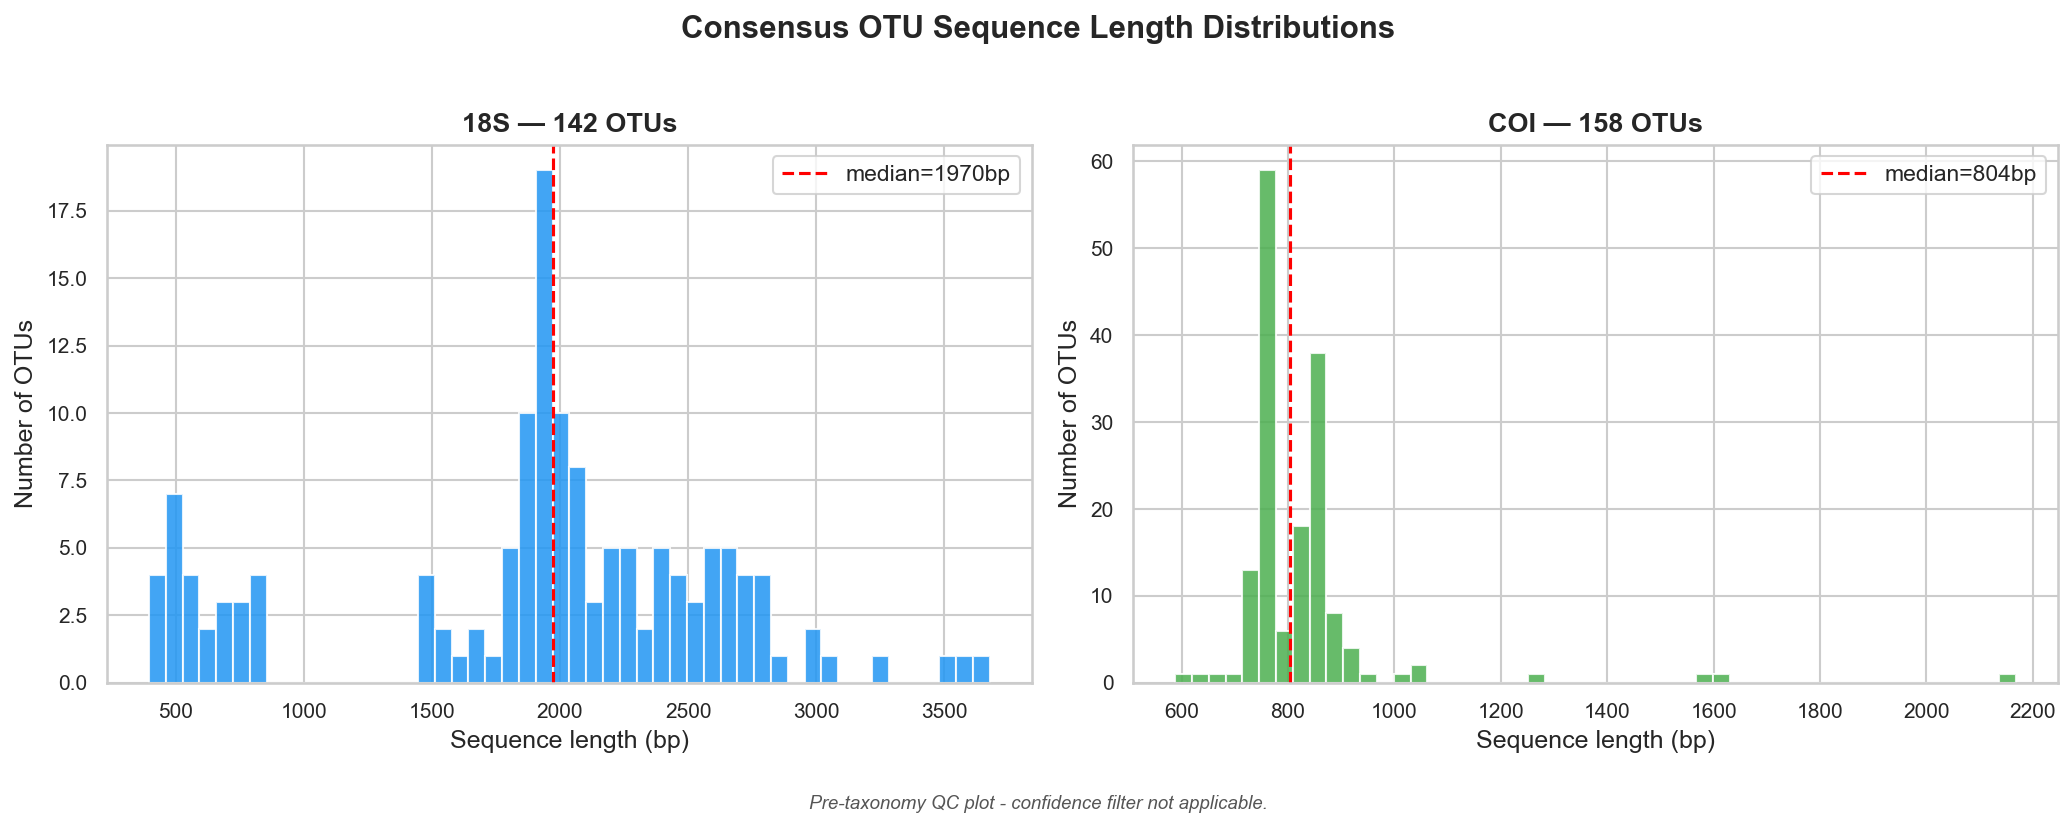

In [6]:
plot_consensus_lengths(BASE, MARKERS)

## Reads per OTU — Consensus Quality Assessment
Each OTU's consensus was built from N reads (from the `seqs=N` field):
- **More reads = higher confidence** in the consensus
- Singleton OTUs (1 read) may be noise or rare taxa
- Top OTUs with 1000+ reads are robust

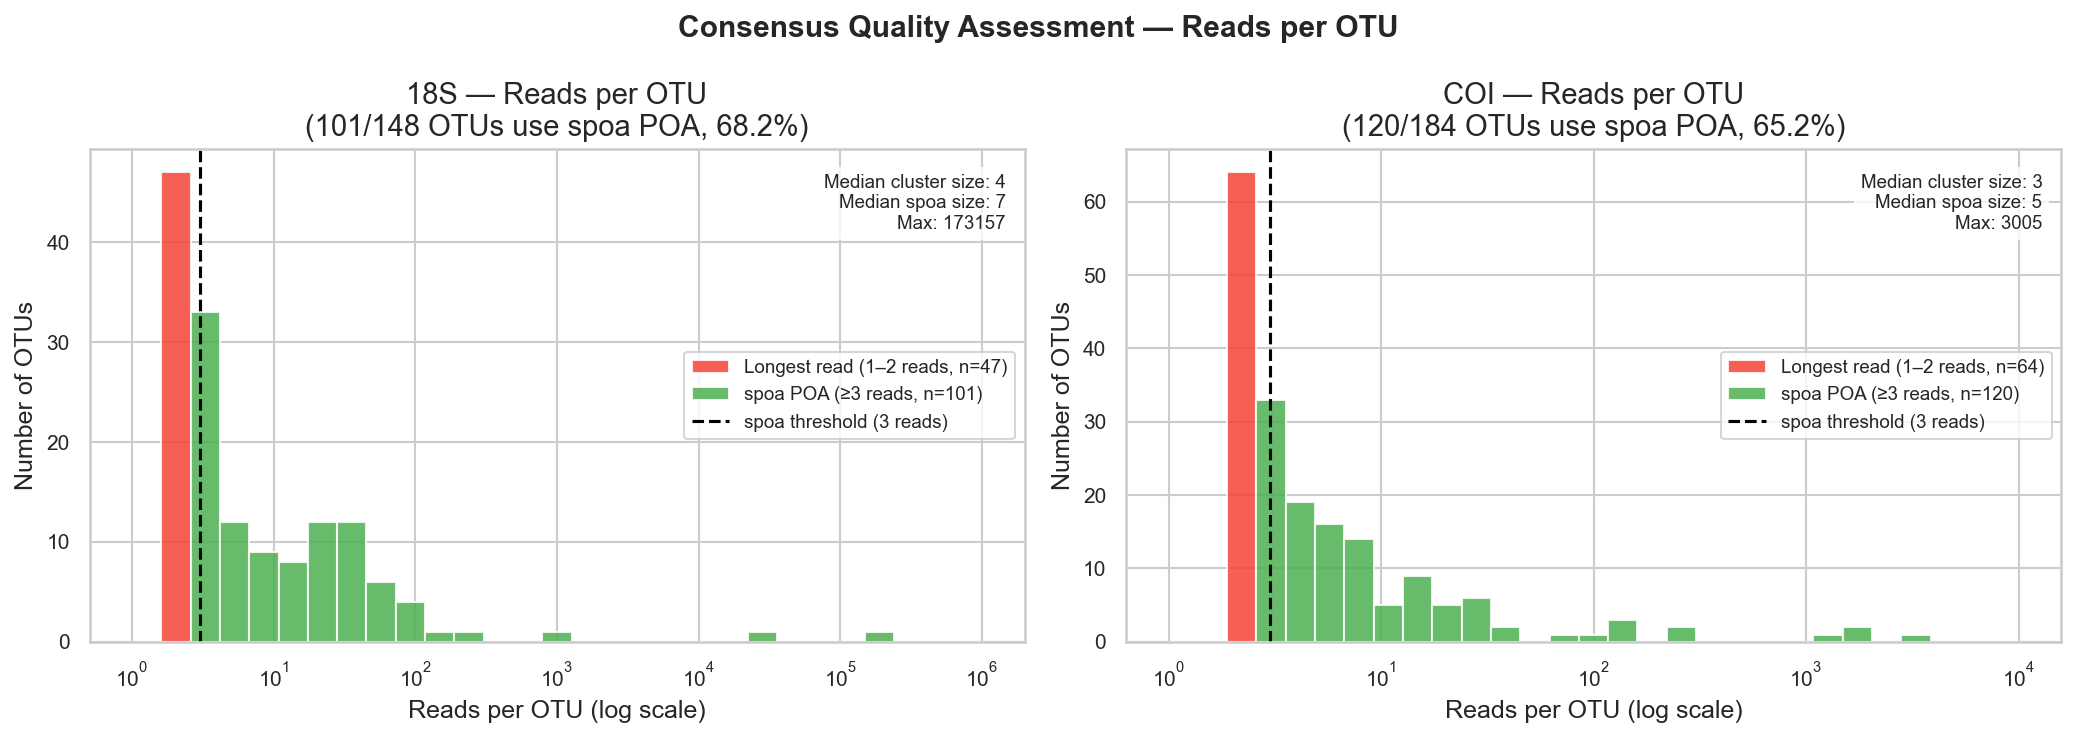

Marker     Total OTUs    spoa (≥3)  Longest rd (<3)   % spoa   Median reads  Max reads
--------------------------------------------------------------------------------
18S               148          101               47    68.2%              4     173157
COI               184          120               64    65.2%              3       3005


In [7]:
plot_reads_per_otu(BASE, MARKERS)

## Read Length Distributions: Before vs After Primer Trimming
Primer trimming removes ~20-25bp from each end (primer sequences).
This validates that primers were found and correctly removed.

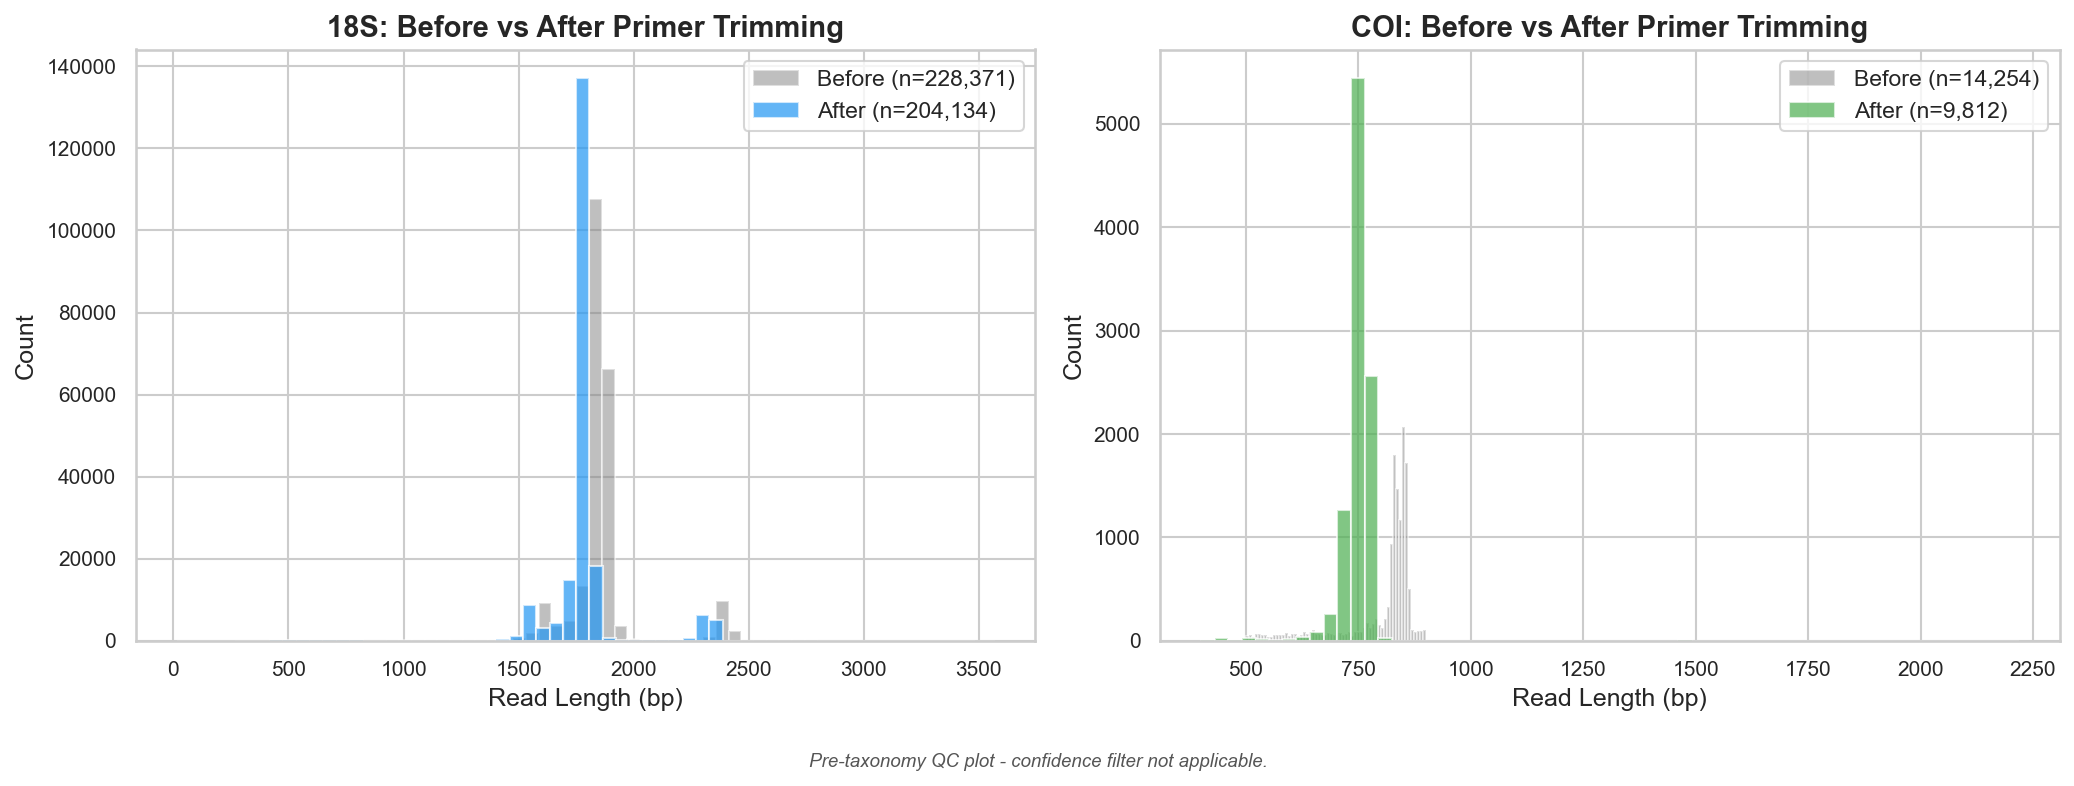

In [8]:
plot_primer_trimming(BASE, MARKERS)

## Reads per Barcode

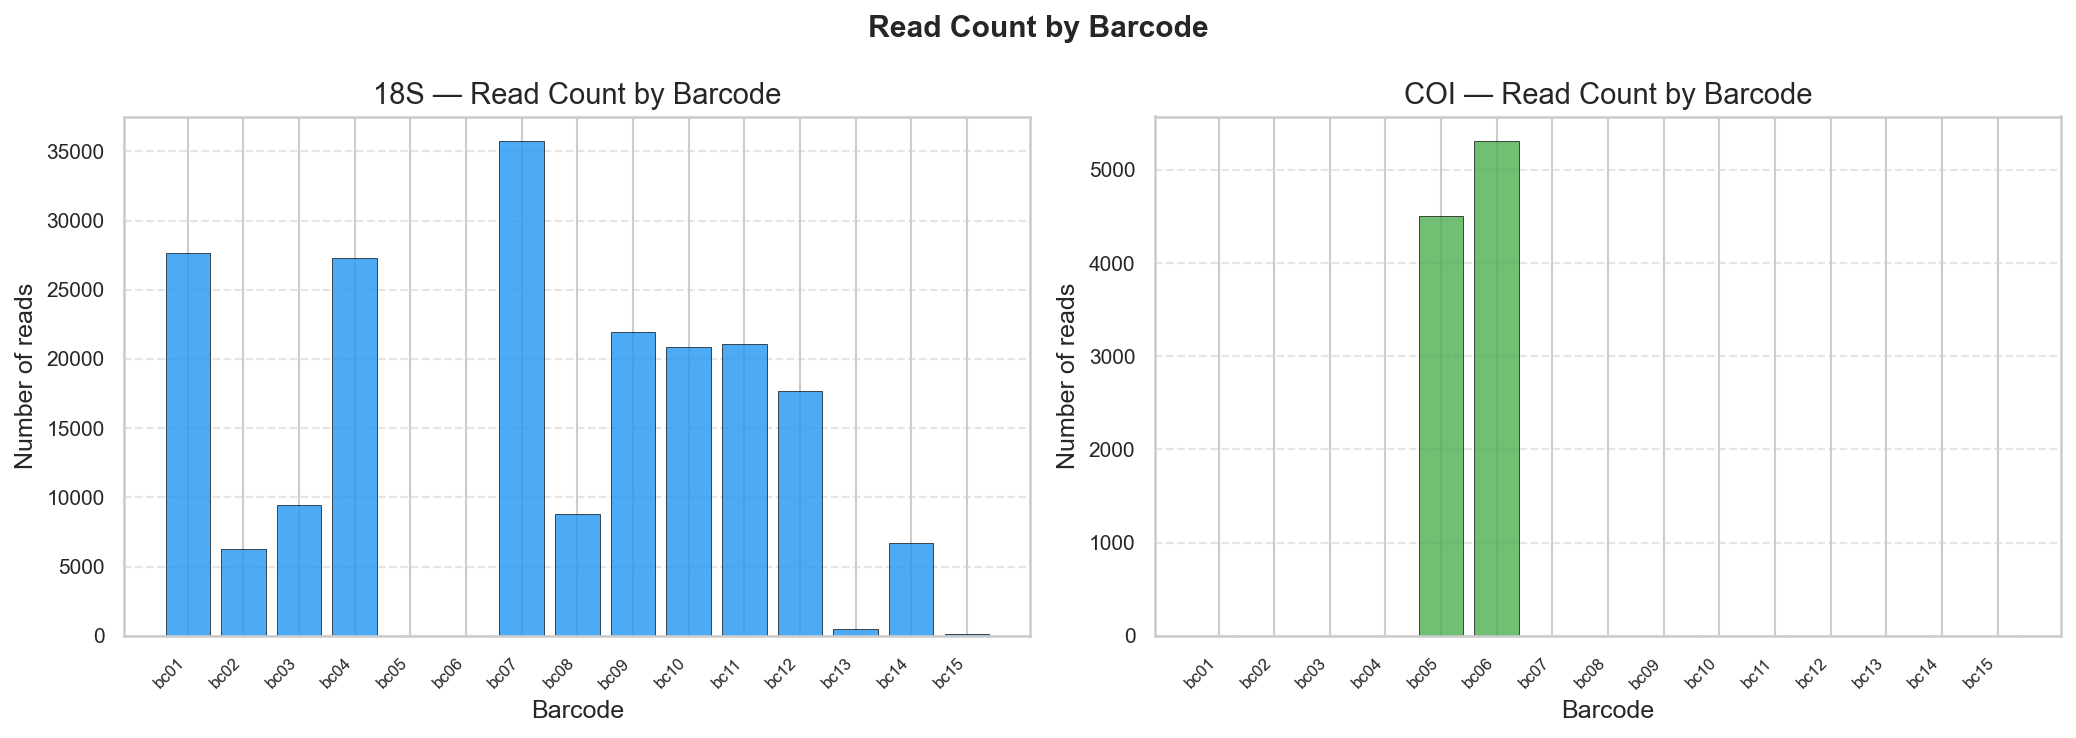

In [9]:
plot_barcode_reads(BASE, MARKERS)

# Part A: 18S Marker Biodiversity Analysis (PR2)

*Objective: Characterize planktonic community structure using 18S rRNA with PR2.*

- **Target:** Full eukaryotic diversity (protists, fungi, micro-metazoa)
- **Amplicon:** ~1400-1800 bp (SSU_1 / ITS_1dr primers)
- **OTUs:** 142 (post-chimera removal)
- **Database:** PR2

## A.1a Broad Taxonomic Structure — Phylum

[18S] division: Unassigned = 1.0% of reads


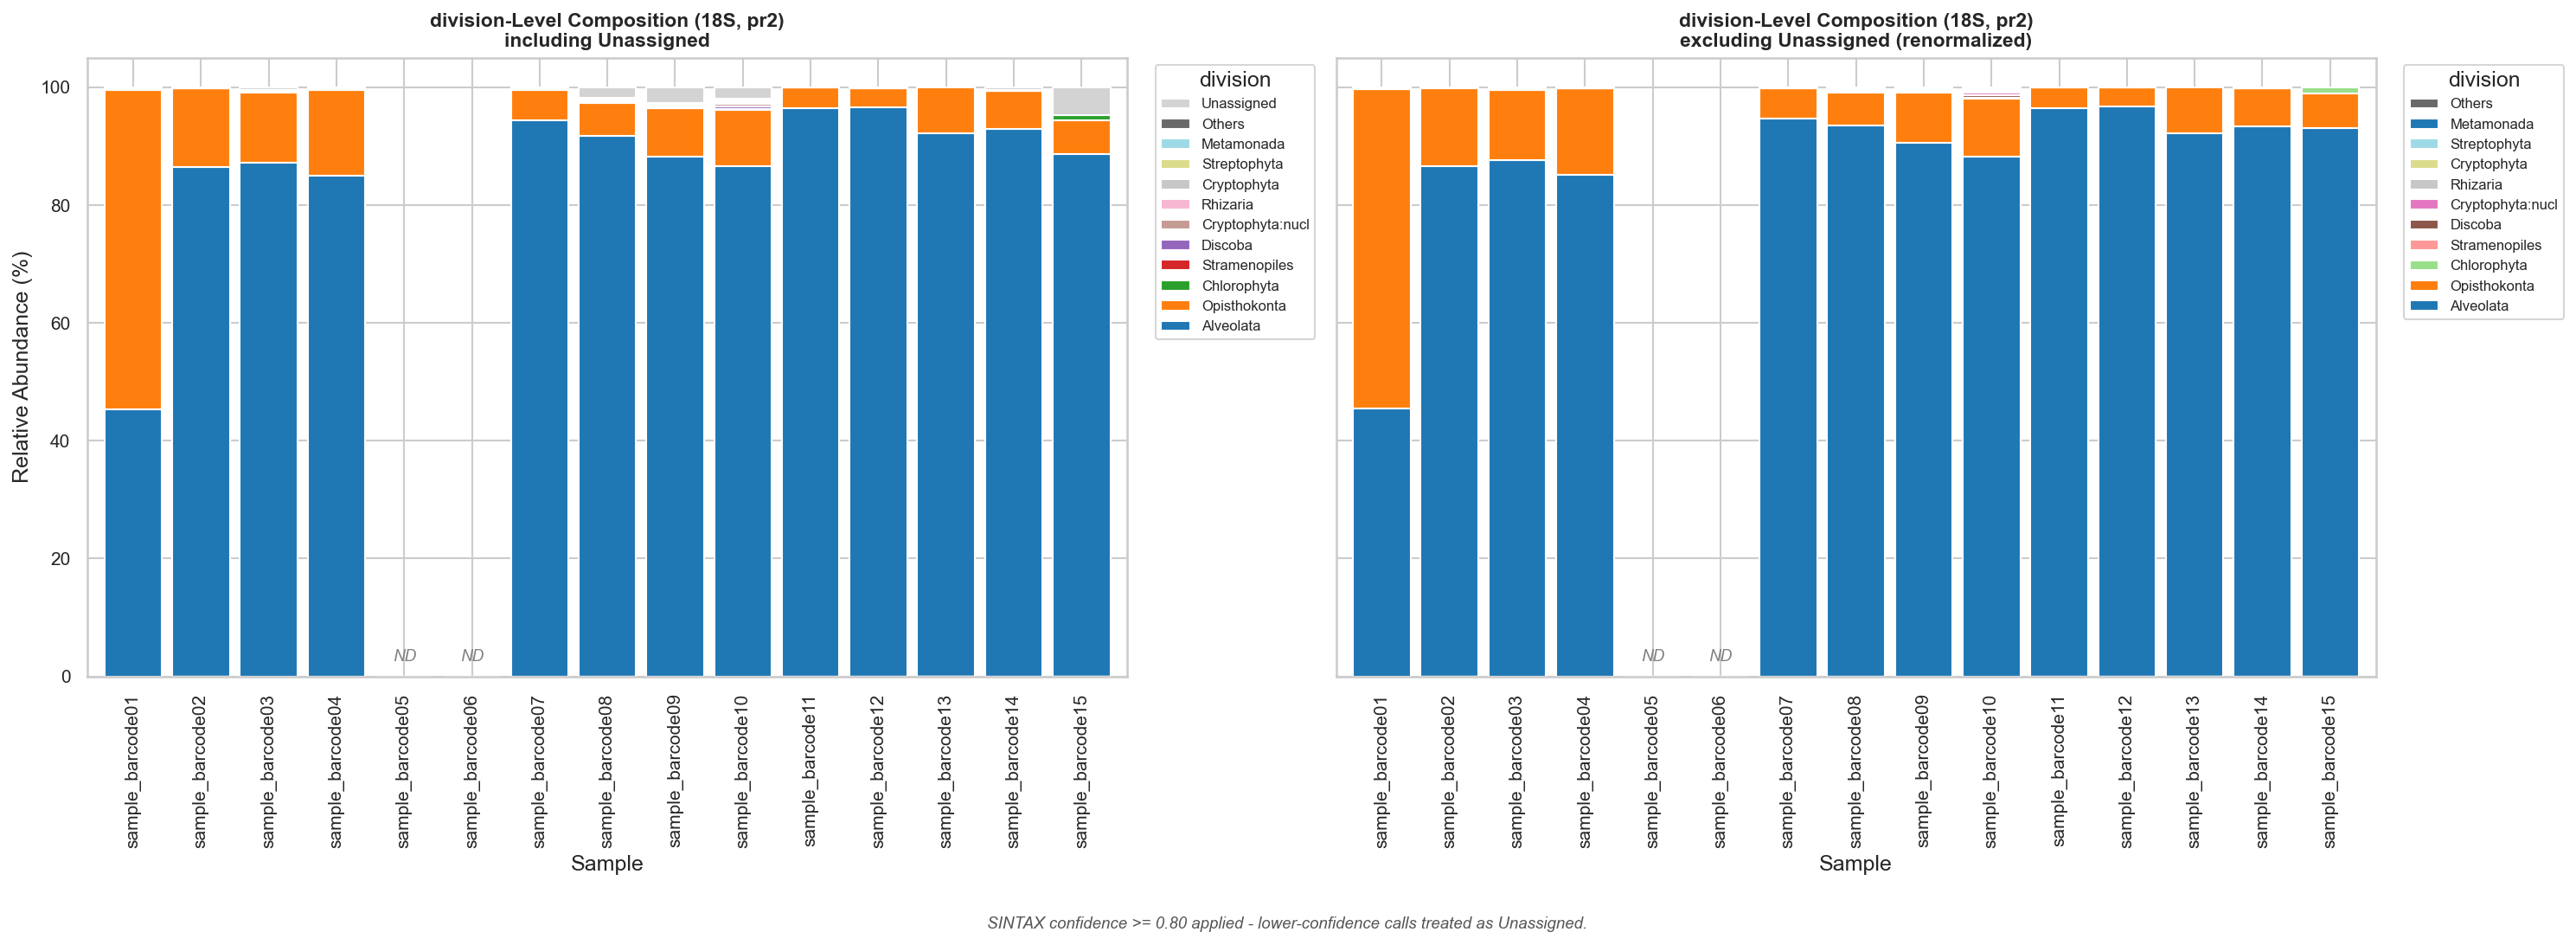

In [10]:
sample_cols_18s = get_sample_cols(df_18s)
broad_rank_18s = get_rank_for_code(prefix_18s, "p")

stacked_bar_compare(
    df_18s,
    broad_rank_18s,
    prefix_18s,
    "18S",
    sample_cols_18s,
    top_n=10,
)

## A.1b Class-Level Breakdown (18S)
**Objective:** See which biological Classes dominate within the broad Phyla.
Expected: Chrysophyceae, Syndiniales, Dinophyceae, Ciliophora in lake water.

[18S] Class: Unassigned = 1.2% of reads


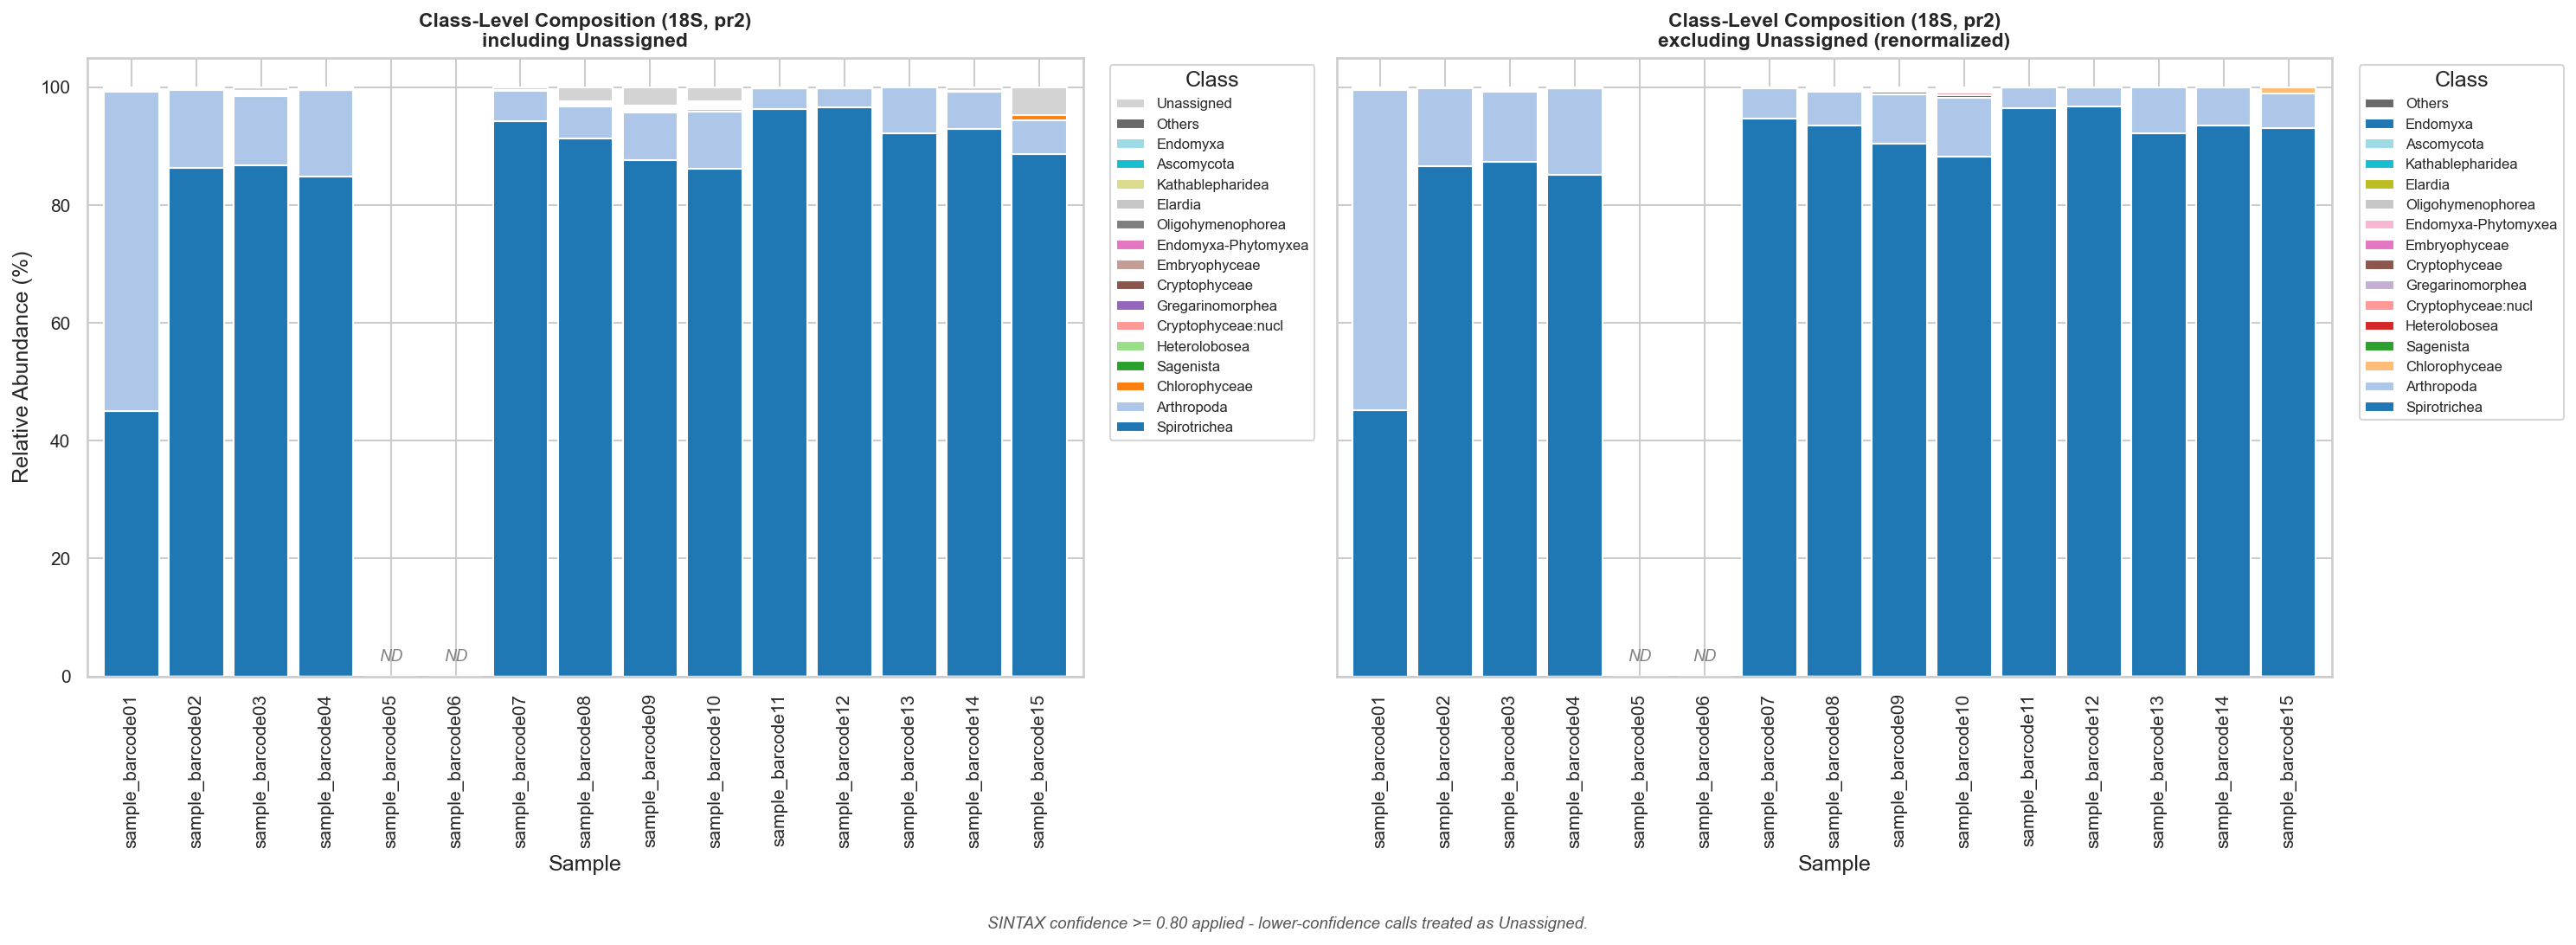

In [11]:
stacked_bar_compare(df_18s, 'Class', prefix_18s, '18S', sample_cols_18s, top_n=15)

## A.2 Order-Level Breakdown (18S)

[18S] Order: Unassigned = 1.3% of reads


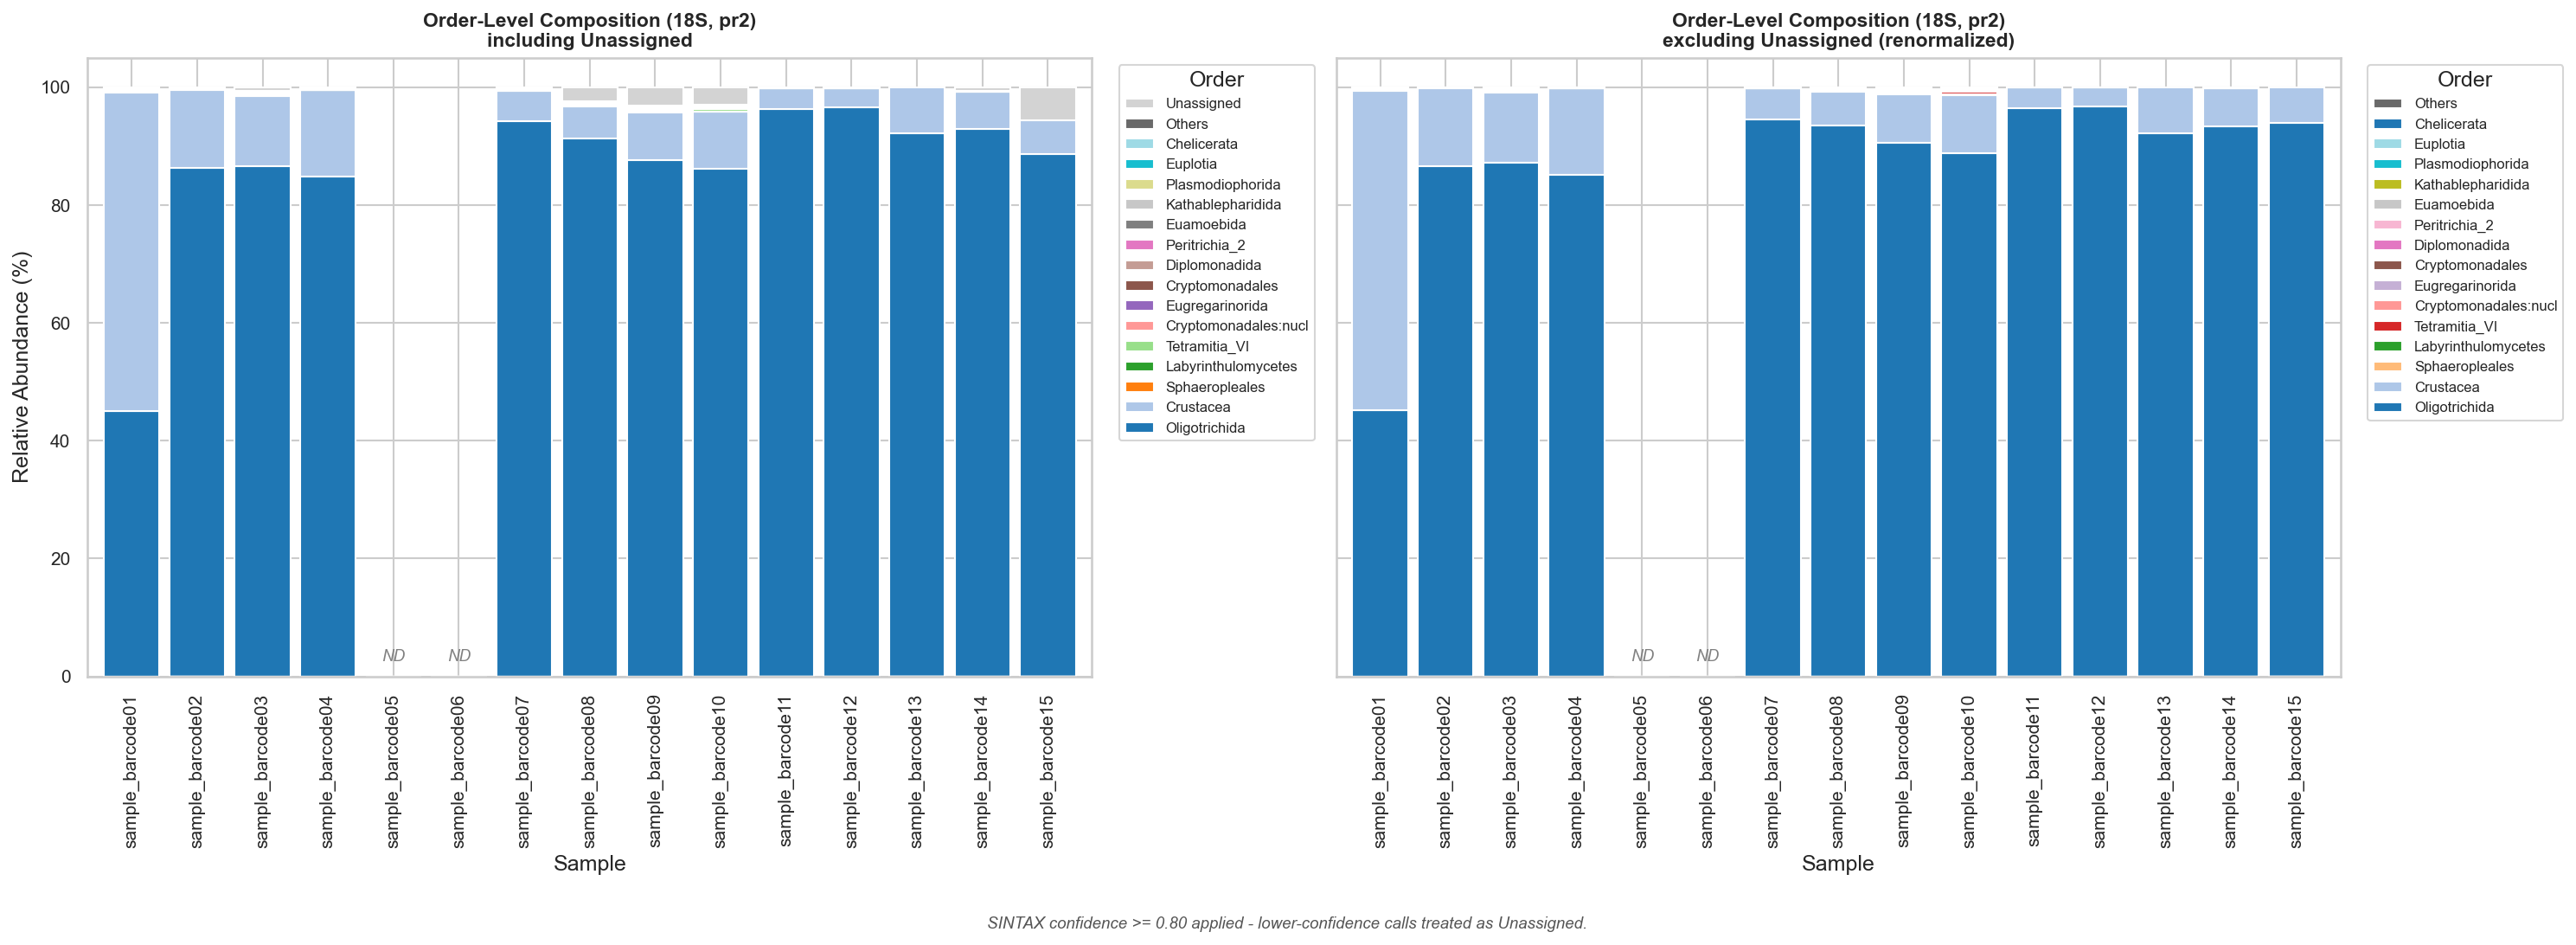

In [12]:
stacked_bar_compare(df_18s, 'Order', prefix_18s, '18S', sample_cols_18s, top_n=15)

## A.3 Genus-Level Top 20 (18S)
Top genera detected with high confidence (>= 0.8).

\\wsl.localhost\Ubuntu\home\ilias\Geno\Leman-eDNA-Pipeline\scripts\notebook_utils.py:688: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top['Total'], y=top.index, palette='viridis', ax=ax)


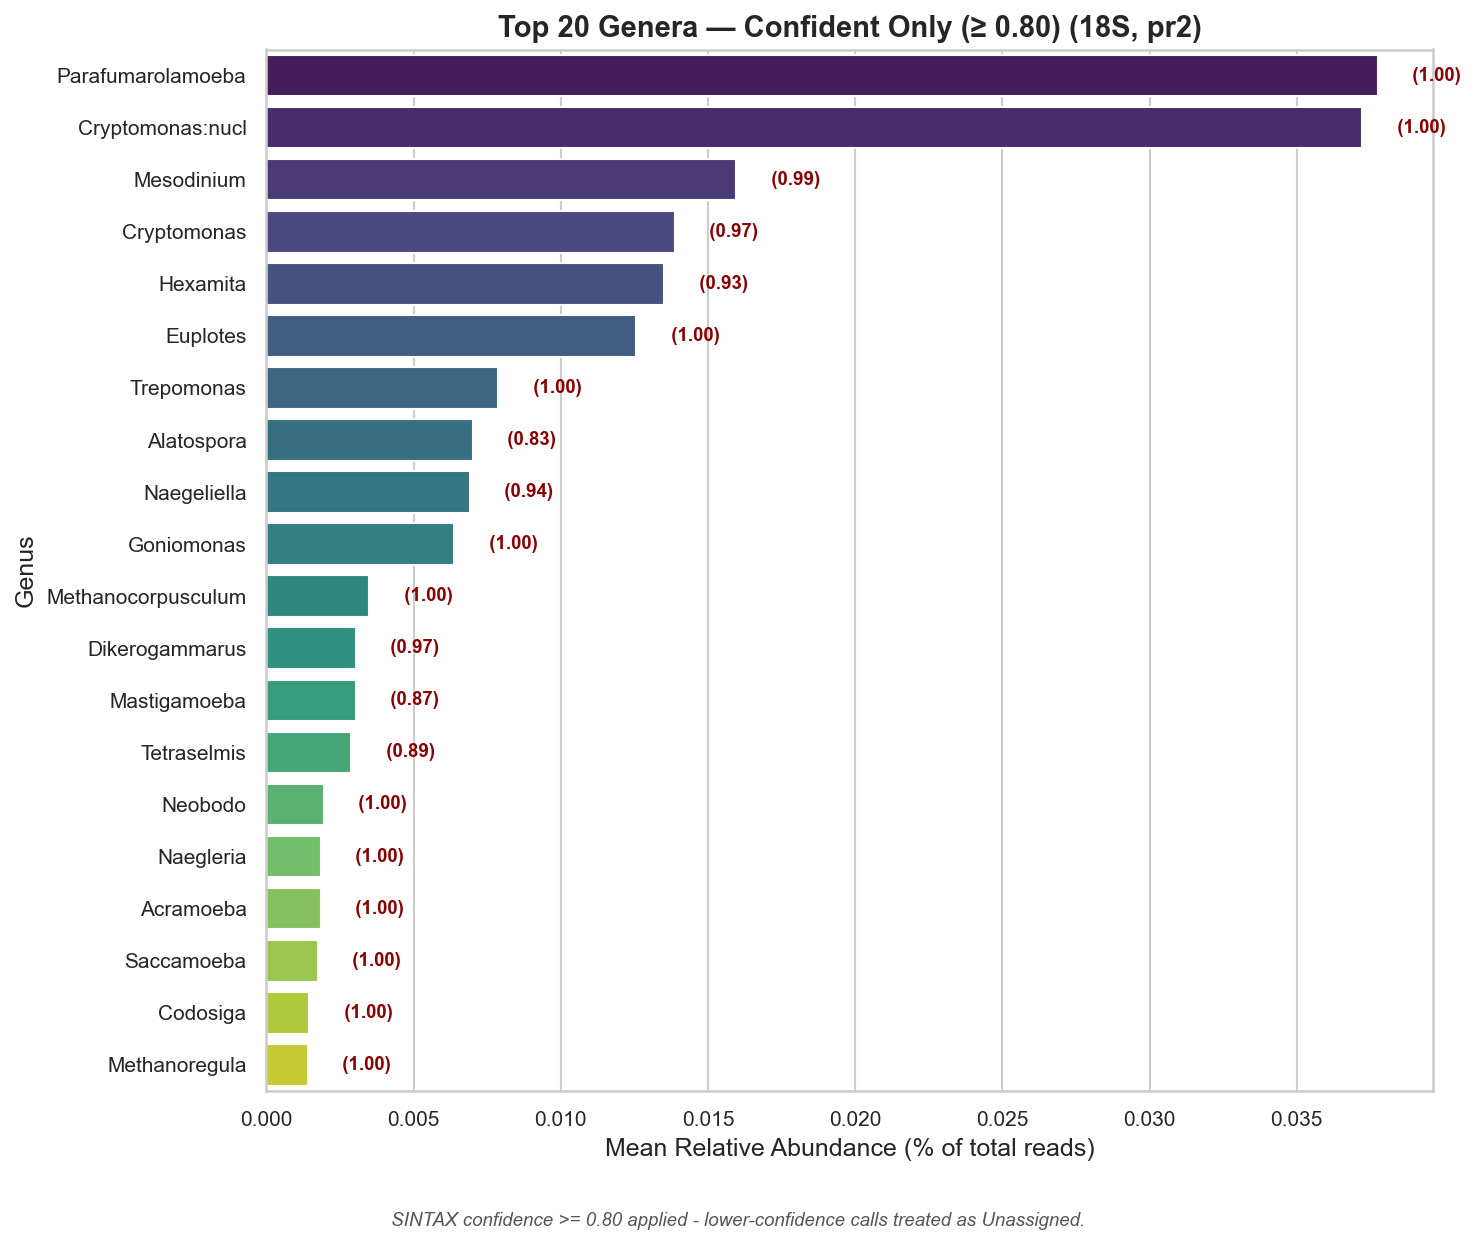

In [13]:
plot_top_genera_confident(df_18s, prefix_18s, '18S', sample_cols_18s)

### Top 20 Genera by Abundance — All Confidences (18S)
All genus assignments ranked by abundance. Bar color = mean confidence.

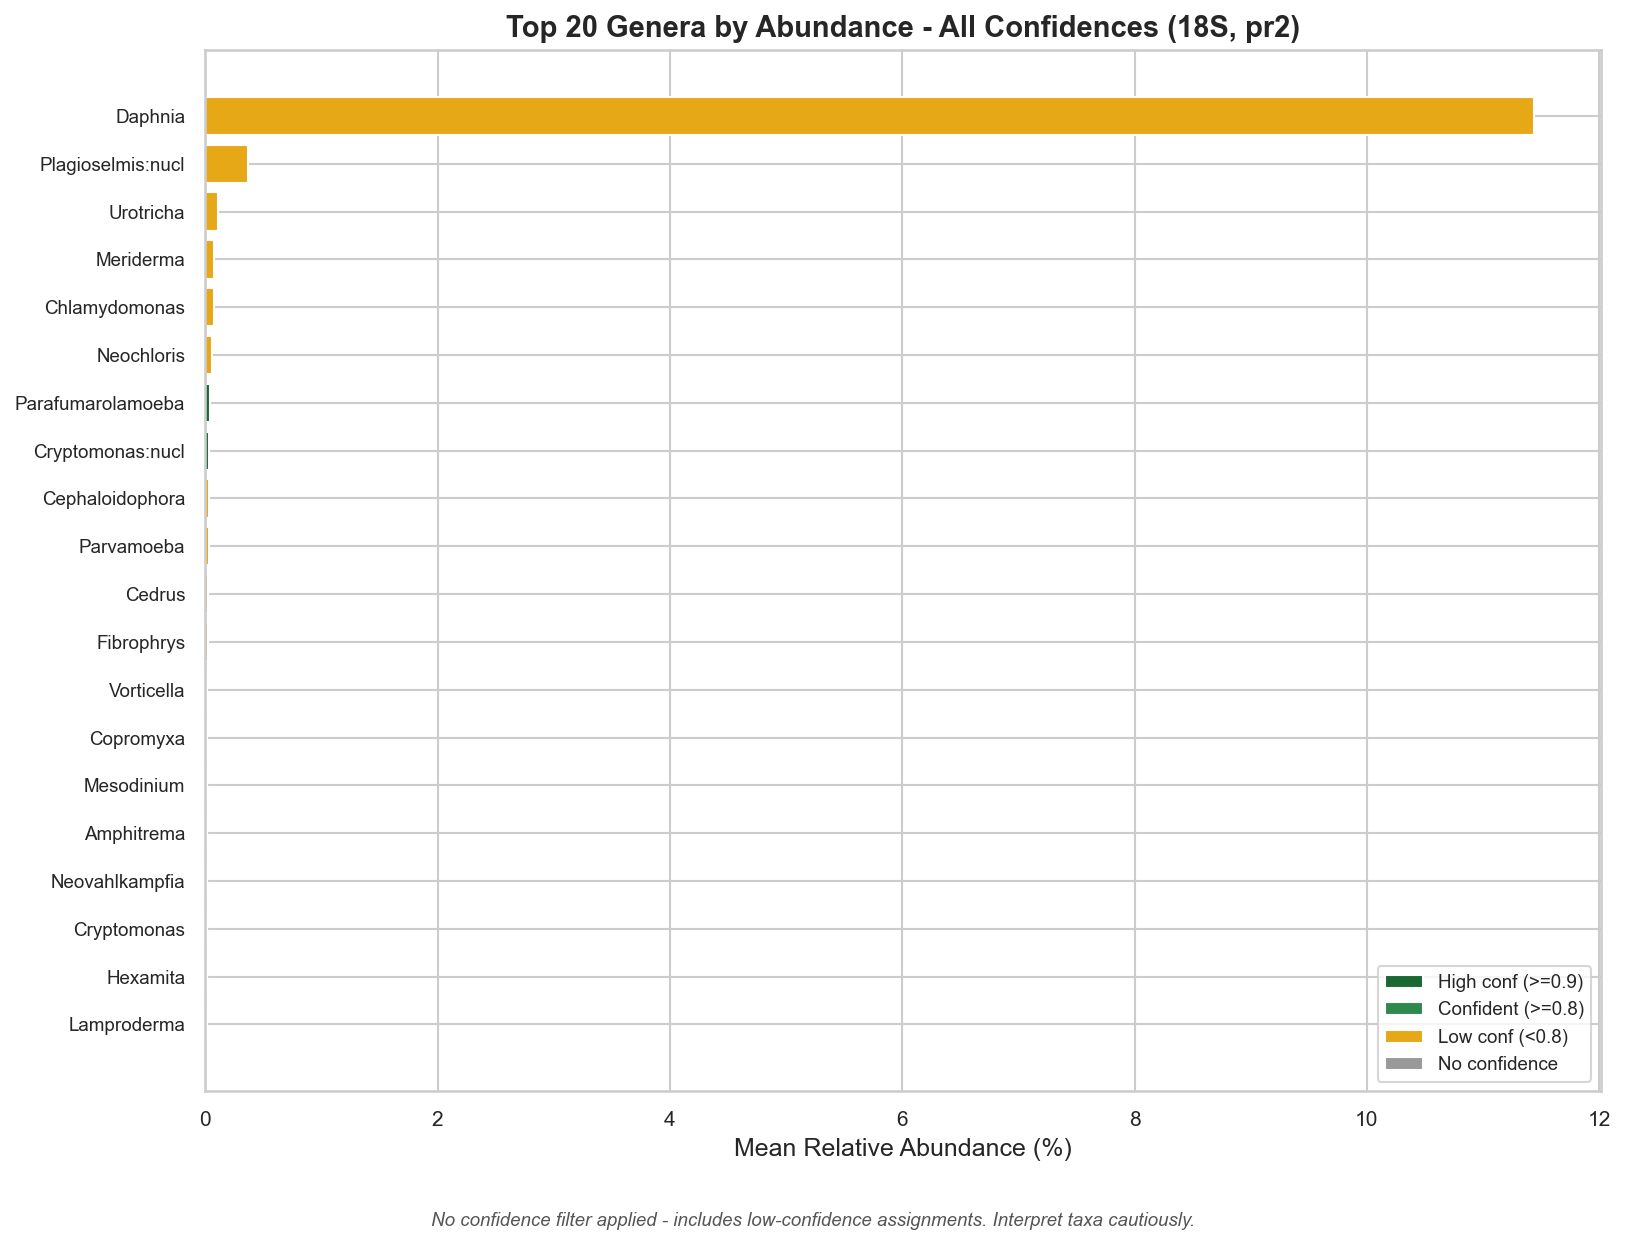

In [14]:
plot_top_genera_all(df_18s, prefix_18s, '18S', sample_cols_18s)

## A.3b Top 20 Eukaryotic Genera (18S, PR2)
Filtered to **Eukaryota domain only** with confidence >= 0.8.

Eukaryota filter: 138/142 OTUs (97.2%)


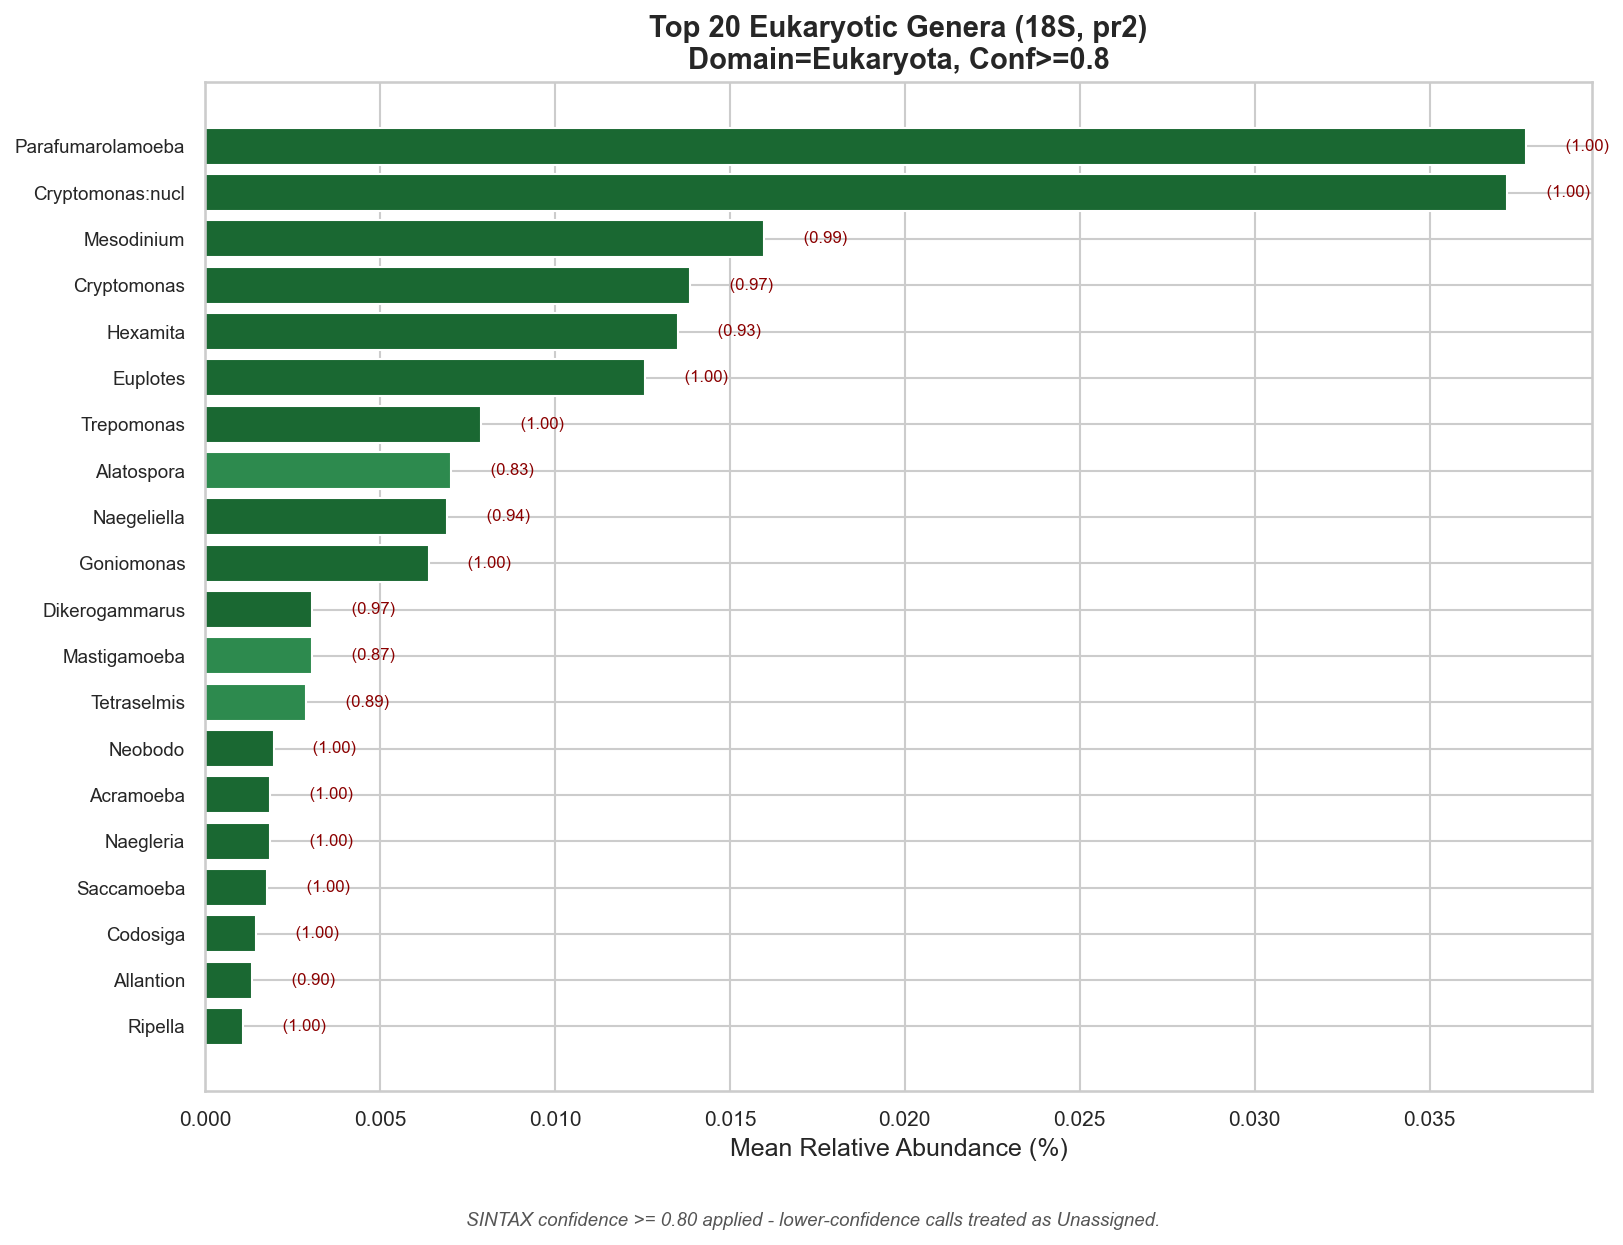

In [15]:
plot_eukaryotic_genera(df_18s, prefix_18s, '18S', sample_cols_18s)

## BLAST Validation — 18S
Top OTUs validated against NCBI GenBank via BLAST.

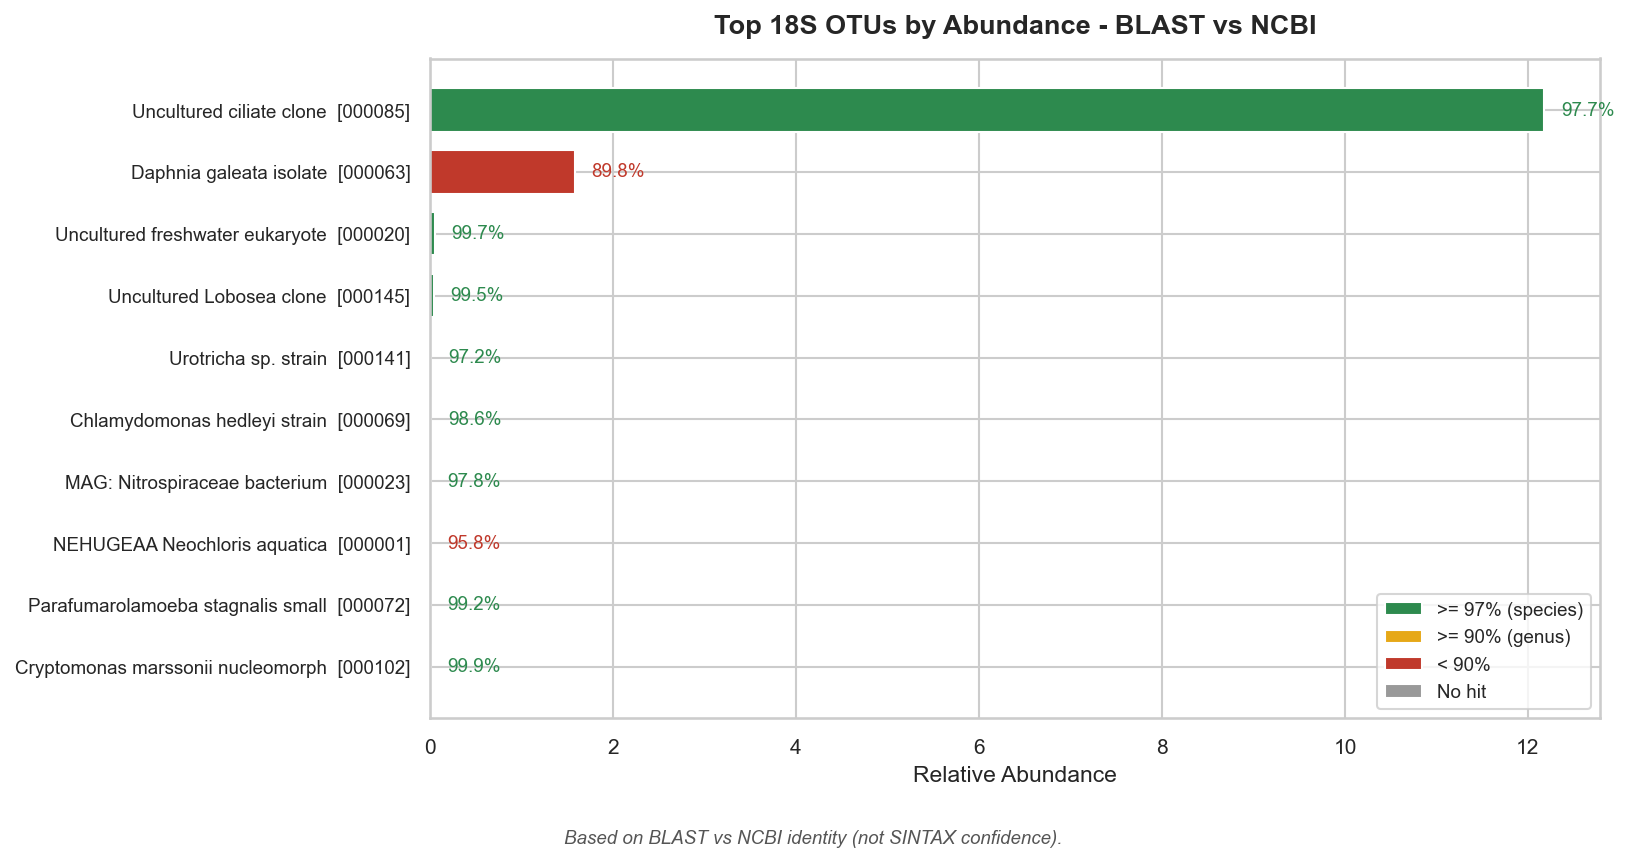

\\wsl.localhost\Ubuntu\home\ilias\Geno\Leman-eDNA-Pipeline\scripts\notebook_utils.py:945: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  .applymap(color_id, subset=['Identity (%)'])


OTU,Abundance,BLAST Top Hit,Identity (%),domain,supergroup,division,class,order,family,genus,species
OTU_18S_000085,12.1812,Uncultured ciliate clone,97.7%,Eukaryota (1.00),TSAR (1.00),Alveolata (1.00),Spirotrichea (1.00),Oligotrichida (0.91),Pelagostrombidiidae (0.83),–,–
OTU_18S_000063,1.5783,Daphnia galeata isolate,89.8%,Eukaryota (1.00),Obazoa (1.00),Opisthokonta (1.00),Arthropoda (1.00),Crustacea (0.98),Branchiopoda (0.98),Daphnia (0.77),Daphnia_pulex (0.59)
OTU_18S_000020,0.0485,Uncultured freshwater eukaryote,99.7%,Eukaryota:nucl (0.61),Cryptista:nucl (0.61),Cryptophyta:nucl (0.61),Cryptophyceae:nucl (0.61),Cryptomonadales:nucl (0.61),Cryptomonadales_X:nucl (0.60),Plagioselmis:nucl (0.54),Plagioselmis_lacustris:nucl (0.54)
OTU_18S_000145,0.0394,Uncultured Lobosea clone,99.5%,Eukaryota (1.00),Amoebozoa (0.79),Evosea (0.76),Variosea (0.75),–,Mariager-Fjord-lineage (0.75),–,–
OTU_18S_000141,0.0140,Urotricha sp. strain,97.2%,Eukaryota (1.00),TSAR (1.00),Alveolata (1.00),Prostomatea (0.79),Prorodontida (0.79),Urotrichidae (0.79),Urotricha (0.78),–
OTU_18S_000069,0.0106,Chlamydomonas hedleyi strain,98.6%,Eukaryota (1.00),Archaeplastida (0.95),Chlorophyta (0.94),Chlorophyceae (0.80),Chlamydomonadales (0.74),–,Chlamydomonas (0.41),–
OTU_18S_000023,0.0095,MAG: Nitrospiraceae bacterium,97.8%,Eukaryota (0.90),Amoebozoa (0.33),Evosea (0.32),Myxogastria_Fuscisporidia (0.29),Stemonitida (0.15),Stemonitidae (0.15),Meriderma (0.04),Meriderma_cribrarioides (0.04)
OTU_18S_000001,0.0089,NEHUGEAA Neochloris aquatica,95.8%,Eukaryota (1.00),Archaeplastida (1.00),Chlorophyta (1.00),Chlorophyceae (0.98),Sphaeropleales (0.92),–,Neochloris (0.38),–
OTU_18S_000072,0.0058,Parafumarolamoeba stagnalis small,99.2%,Eukaryota (1.00),Excavata (1.00),Discoba (1.00),Heterolobosea (1.00),Tetramitia_VI (1.00),–,Parafumarolamoeba (1.00),Parafumarolamoeba_stagnalis (0.92)
OTU_18S_000102,0.0048,Cryptomonas marssonii nucleomorph,99.9%,Eukaryota:nucl (1.00),Cryptista:nucl (1.00),Cryptophyta:nucl (1.00),Cryptophyceae:nucl (1.00),Cryptomonadales:nucl (1.00),Cryptomonadales_X:nucl (1.00),Cryptomonas:nucl (1.00),Cryptomonas_marssonii:nucl (1.00)


In [16]:
plot_blast_hits(str(BASE / 'blast_results/blast_top10_abundance_18S.txt'), '18S', 'Abundance')
blast_vs_sintax_table(str(BASE / 'blast_results/blast_top10_abundance_18S.txt'), df_18s, prefix_18s, '18S')

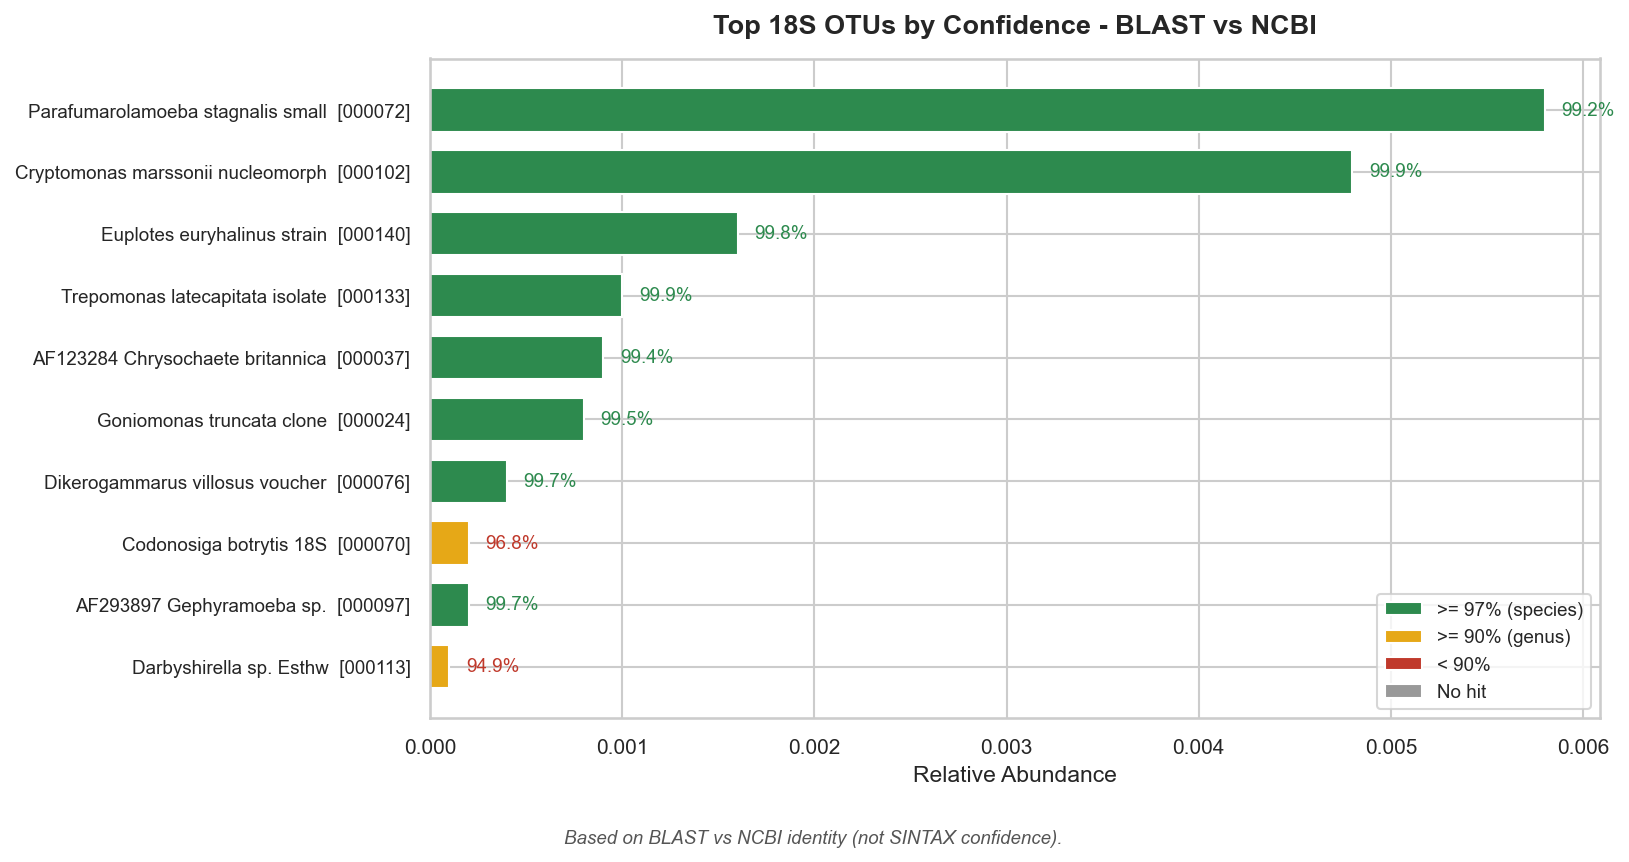

\\wsl.localhost\Ubuntu\home\ilias\Geno\Leman-eDNA-Pipeline\scripts\notebook_utils.py:945: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  .applymap(color_id, subset=['Identity (%)'])


OTU,Abundance,BLAST Top Hit,Identity (%),domain,supergroup,division,class,order,family,genus,species
OTU_18S_000024,0.0008,Goniomonas truncata clone,99.5%,Eukaryota (1.00),Cryptista (1.00),Cryptophyta (1.00),Cryptophyceae (1.00),Goniomonadales (1.00),–,Goniomonas (1.00),Goniomonas_truncata (1.00)
OTU_18S_000113,0.0001,Darbyshirella sp. Esthw,94.9%,Eukaryota (1.00),Amoebozoa (1.00),Evosea (1.00),Variosea (1.00),–,Ischnamoebidae (1.00),Darbyshirella (1.00),Darbyshirella_terrestris (1.00)
OTU_18S_000133,0.0010,Trepomonas latecapitata isolate,99.9%,Eukaryota (1.00),Excavata (1.00),Metamonada (1.00),–,Diplomonadida (1.00),Hexamitidae (1.00),Trepomonas (1.00),Trepomonas_latecapitata (1.00)
OTU_18S_000097,0.0002,AF293897 Gephyramoeba sp.,99.7%,Eukaryota (1.00),Amoebozoa (1.00),Evosea (1.00),Variosea (1.00),Fractovitellida (1.00),Acramoebidae (1.00),Acramoeba (1.00),Acramoeba_dendroida (1.00)
OTU_18S_000102,0.0048,Cryptomonas marssonii nucleomorph,99.9%,Eukaryota:nucl (1.00),Cryptista:nucl (1.00),Cryptophyta:nucl (1.00),Cryptophyceae:nucl (1.00),Cryptomonadales:nucl (1.00),Cryptomonadales_X:nucl (1.00),Cryptomonas:nucl (1.00),Cryptomonas_marssonii:nucl (1.00)
OTU_18S_000070,0.0002,Codonosiga botrytis 18S,96.8%,Eukaryota (1.00),Obazoa (1.00),Opisthokonta (1.00),Choanoflagellatea (1.00),Craspedida (1.00),Monosigidae_Group_A (1.00),Codosiga (1.00),Codosiga_botrytis (1.00)
OTU_18S_000076,0.0004,Dikerogammarus villosus voucher,99.7%,Eukaryota (1.00),Obazoa (1.00),Opisthokonta (1.00),Arthropoda (1.00),Crustacea (1.00),Malacostraca (1.00),Dikerogammarus (0.97),Dikerogammarus_villosus (0.97)
OTU_18S_000140,0.0016,Euplotes euryhalinus strain,99.8%,Eukaryota (1.00),TSAR (1.00),Alveolata (1.00),Spirotrichea (1.00),Euplotia (1.00),Euplotidae (1.00),Euplotes (1.00),Euplotes_euryhalinus (0.97)
OTU_18S_000037,0.0009,AF123284 Chrysochaete britannica,99.4%,Eukaryota (1.00),TSAR (1.00),Stramenopiles (0.99),Chrysophyceae (0.98),Hibberdiales (0.94),Hibberdiaceae (0.94),Naegeliella (0.94),Naegeliella_flagellifera (0.94)
OTU_18S_000072,0.0058,Parafumarolamoeba stagnalis small,99.2%,Eukaryota (1.00),Excavata (1.00),Discoba (1.00),Heterolobosea (1.00),Tetramitia_VI (1.00),–,Parafumarolamoeba (1.00),Parafumarolamoeba_stagnalis (0.92)


In [17]:
plot_blast_hits(str(BASE / 'blast_results/blast_top10_confidence_18S.txt'), '18S', 'Confidence')
blast_vs_sintax_table(str(BASE / 'blast_results/blast_top10_confidence_18S.txt'), df_18s, prefix_18s, '18S')

# Part B: COI Marker Biodiversity Analysis (MIDORI2)

*Objective: Characterize metazoan community using COI with MIDORI2.*

- **Target:** Animals (metazoa), especially invertebrates
- **Amplicon:** ~658 bp (LCO1490 / HCO2198 Folmer primers)
- **OTUs:** 195 (post-chimera removal)
- **Database:** MIDORI2
- **Note:** Only 2 barcodes (05, 06) contained COI reads — limited diversity expected.

In [18]:
# Clean COI taxonomy names
df_coi = clean_taxonomy_names(df_coi_raw.copy(), prefix_coi)
sample_cols_coi = get_sample_cols(df_coi)

## B.1a Broad Taxonomic Structure (COI)

[COI] Phylum: Unassigned = 59.0% of reads


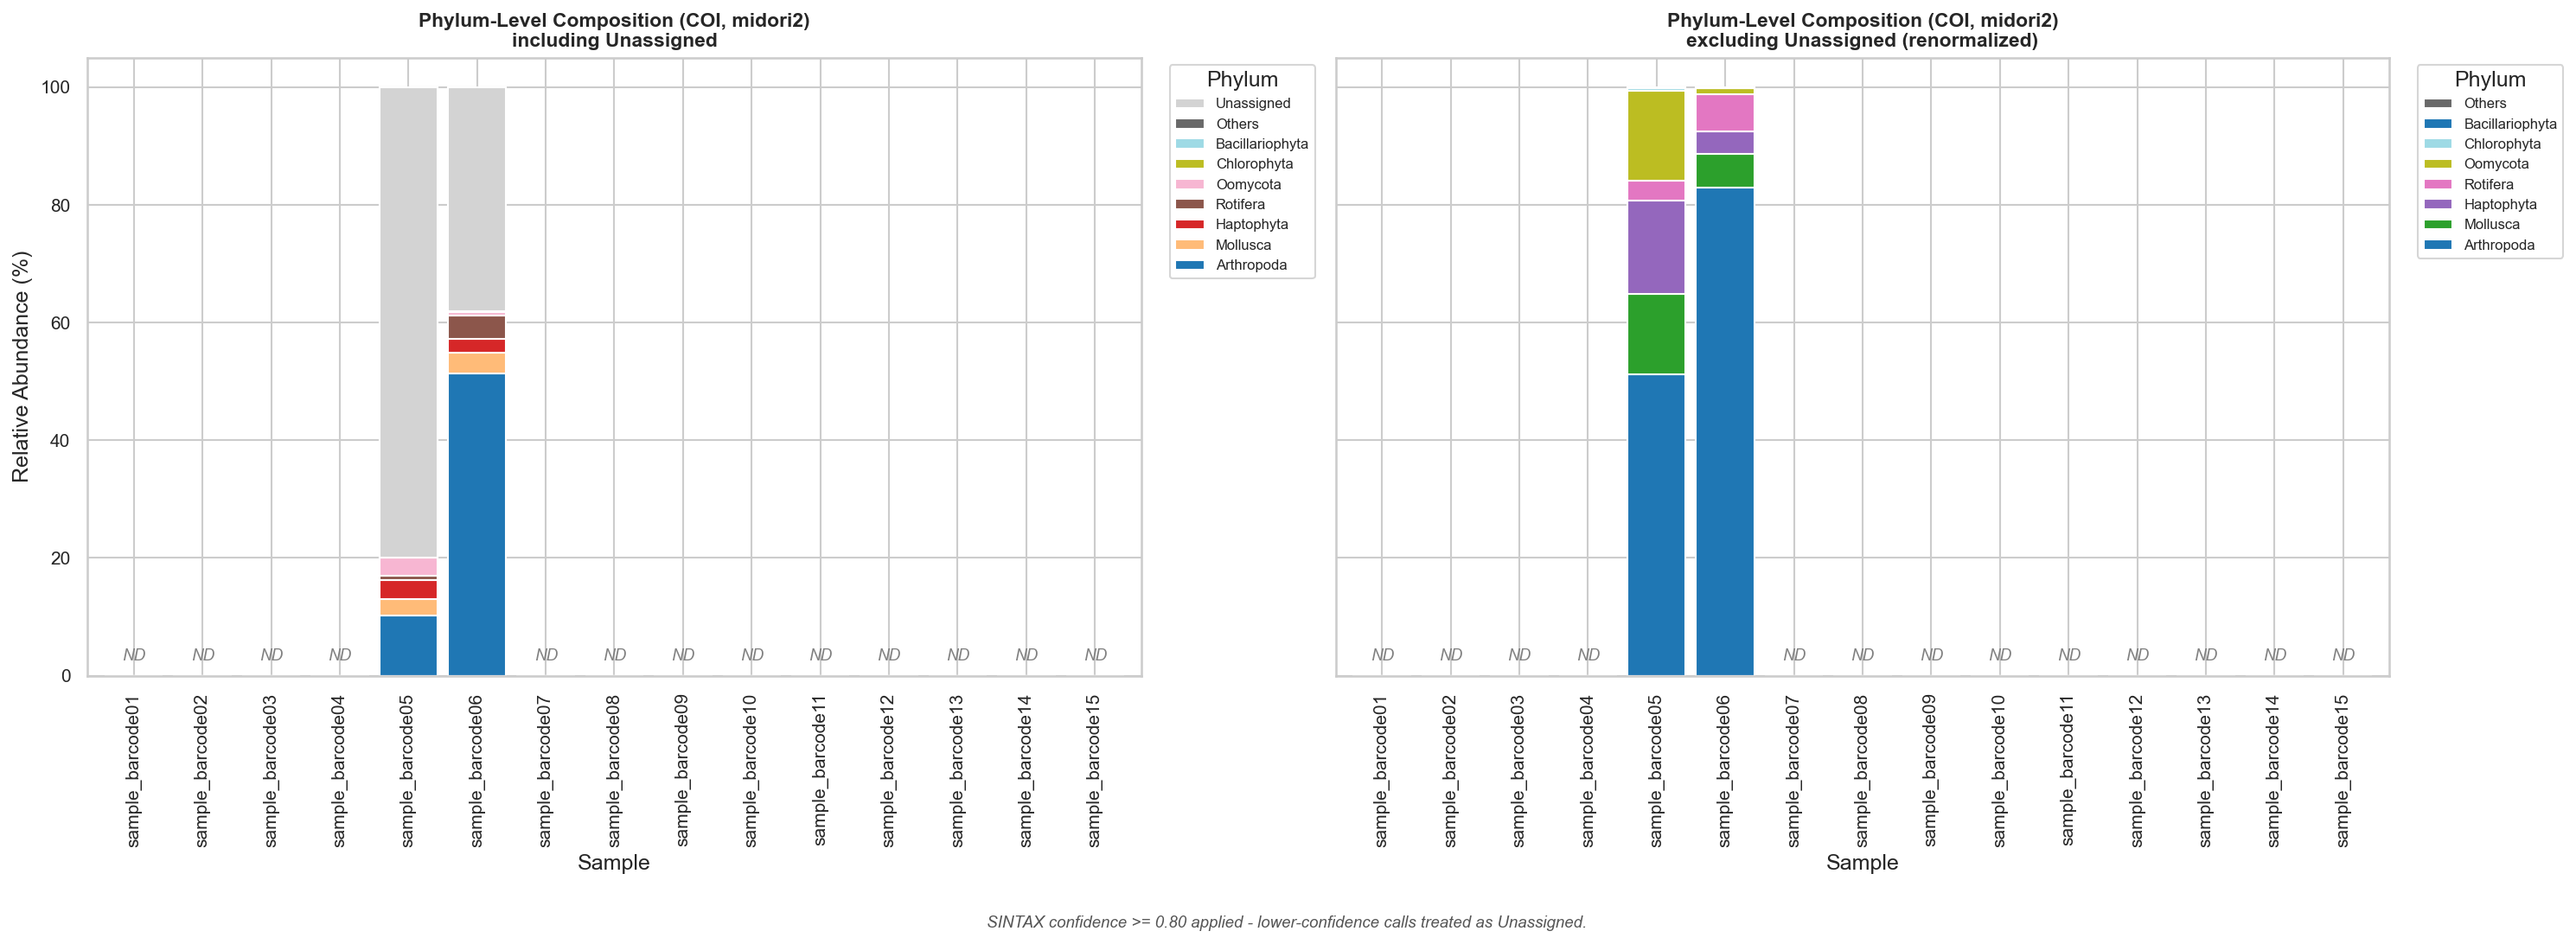

In [19]:
stacked_bar_compare(df_coi, 'Phylum', prefix_coi, 'COI', sample_cols_coi, top_n=10)

## B.1b Class-Level Breakdown (COI, MIDORI2)
Expected for lake water COI: Rotifera, Maxillopoda, Branchiopoda, Insecta.

[COI] Class: Unassigned = 61.7% of reads


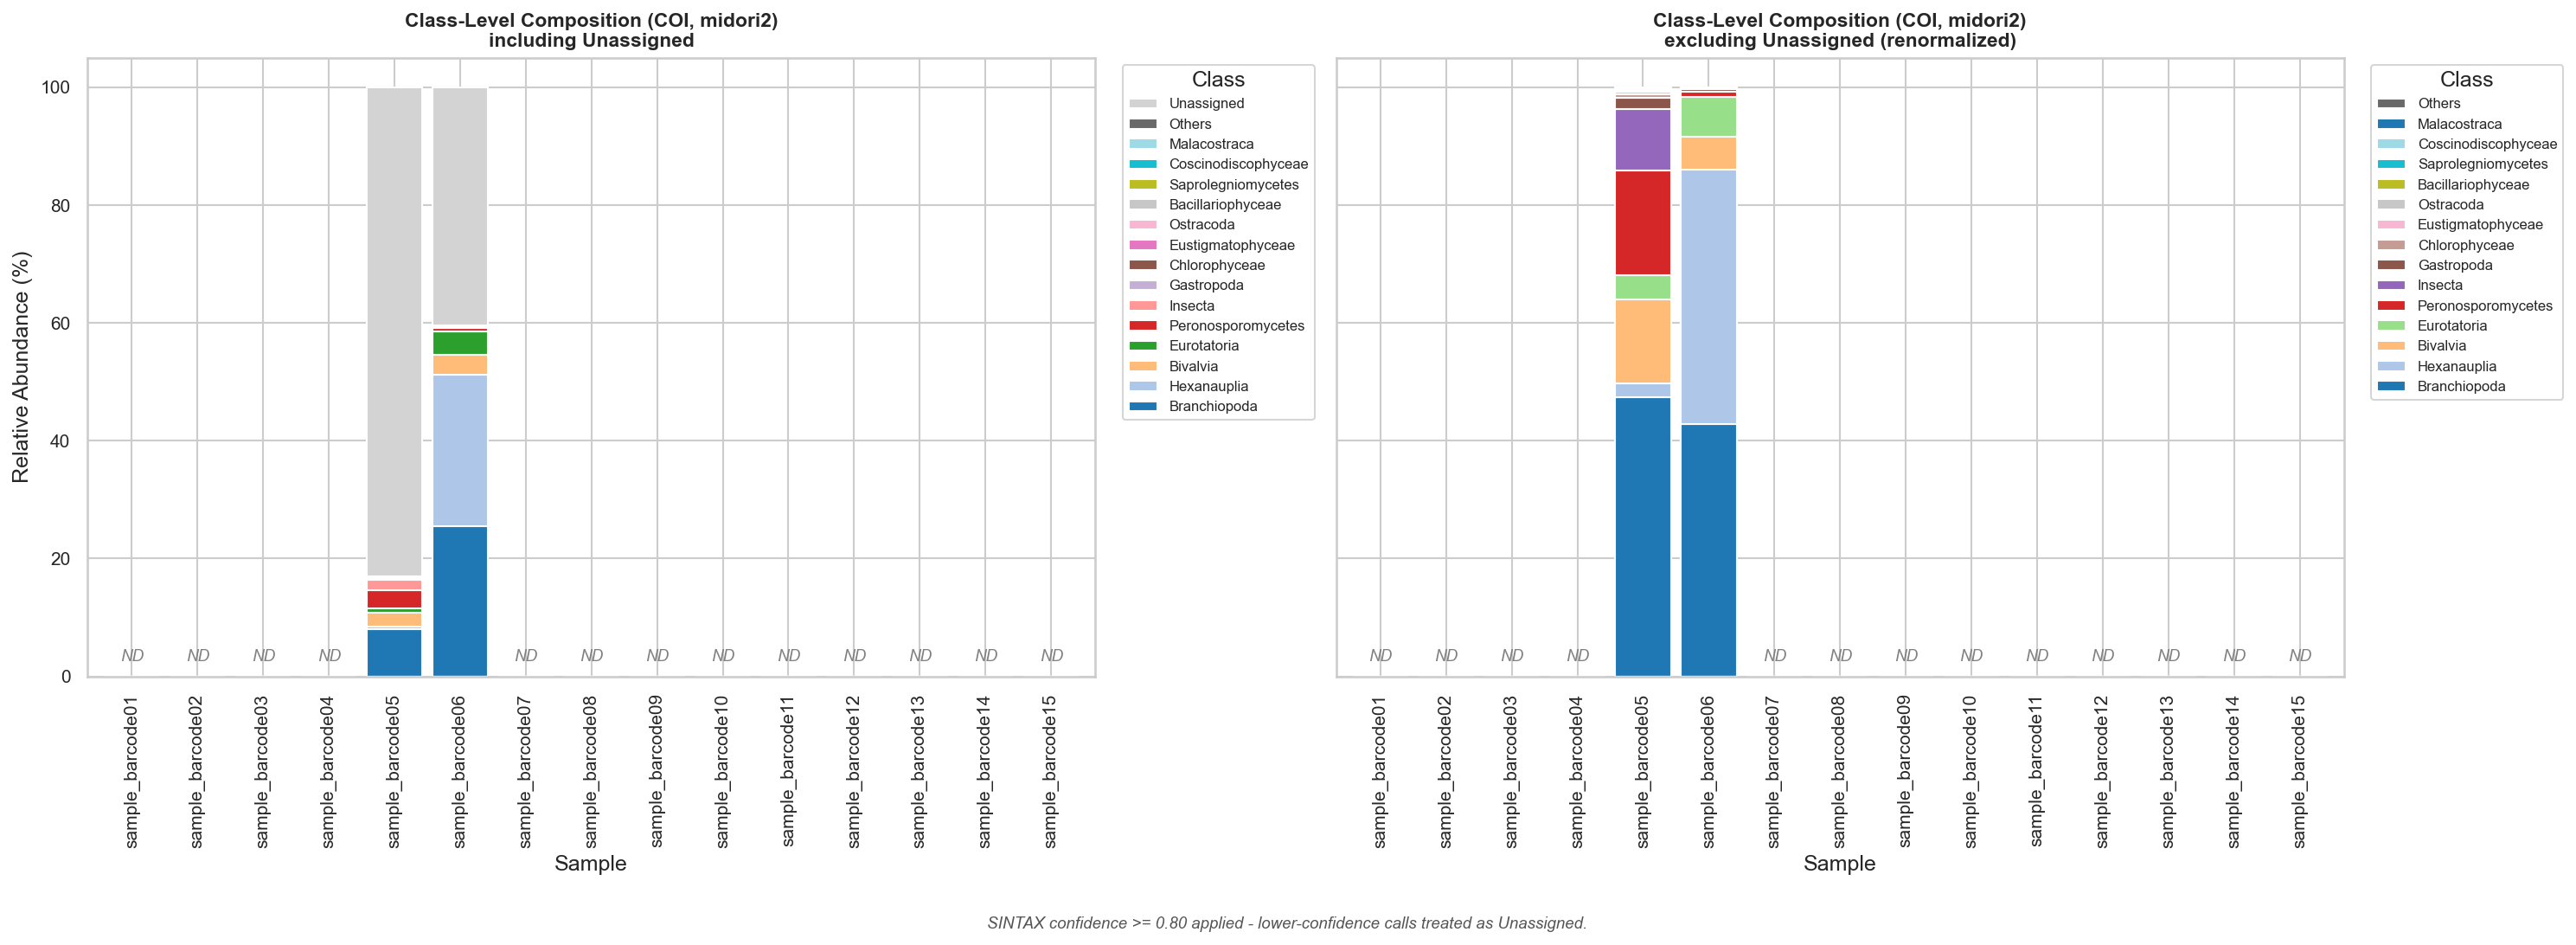

In [20]:
stacked_bar_compare(df_coi, 'Class', prefix_coi, 'COI', sample_cols_coi, top_n=15)

## B.2 Order-Level Breakdown (COI)

[COI] Order: Unassigned = 59.1% of reads


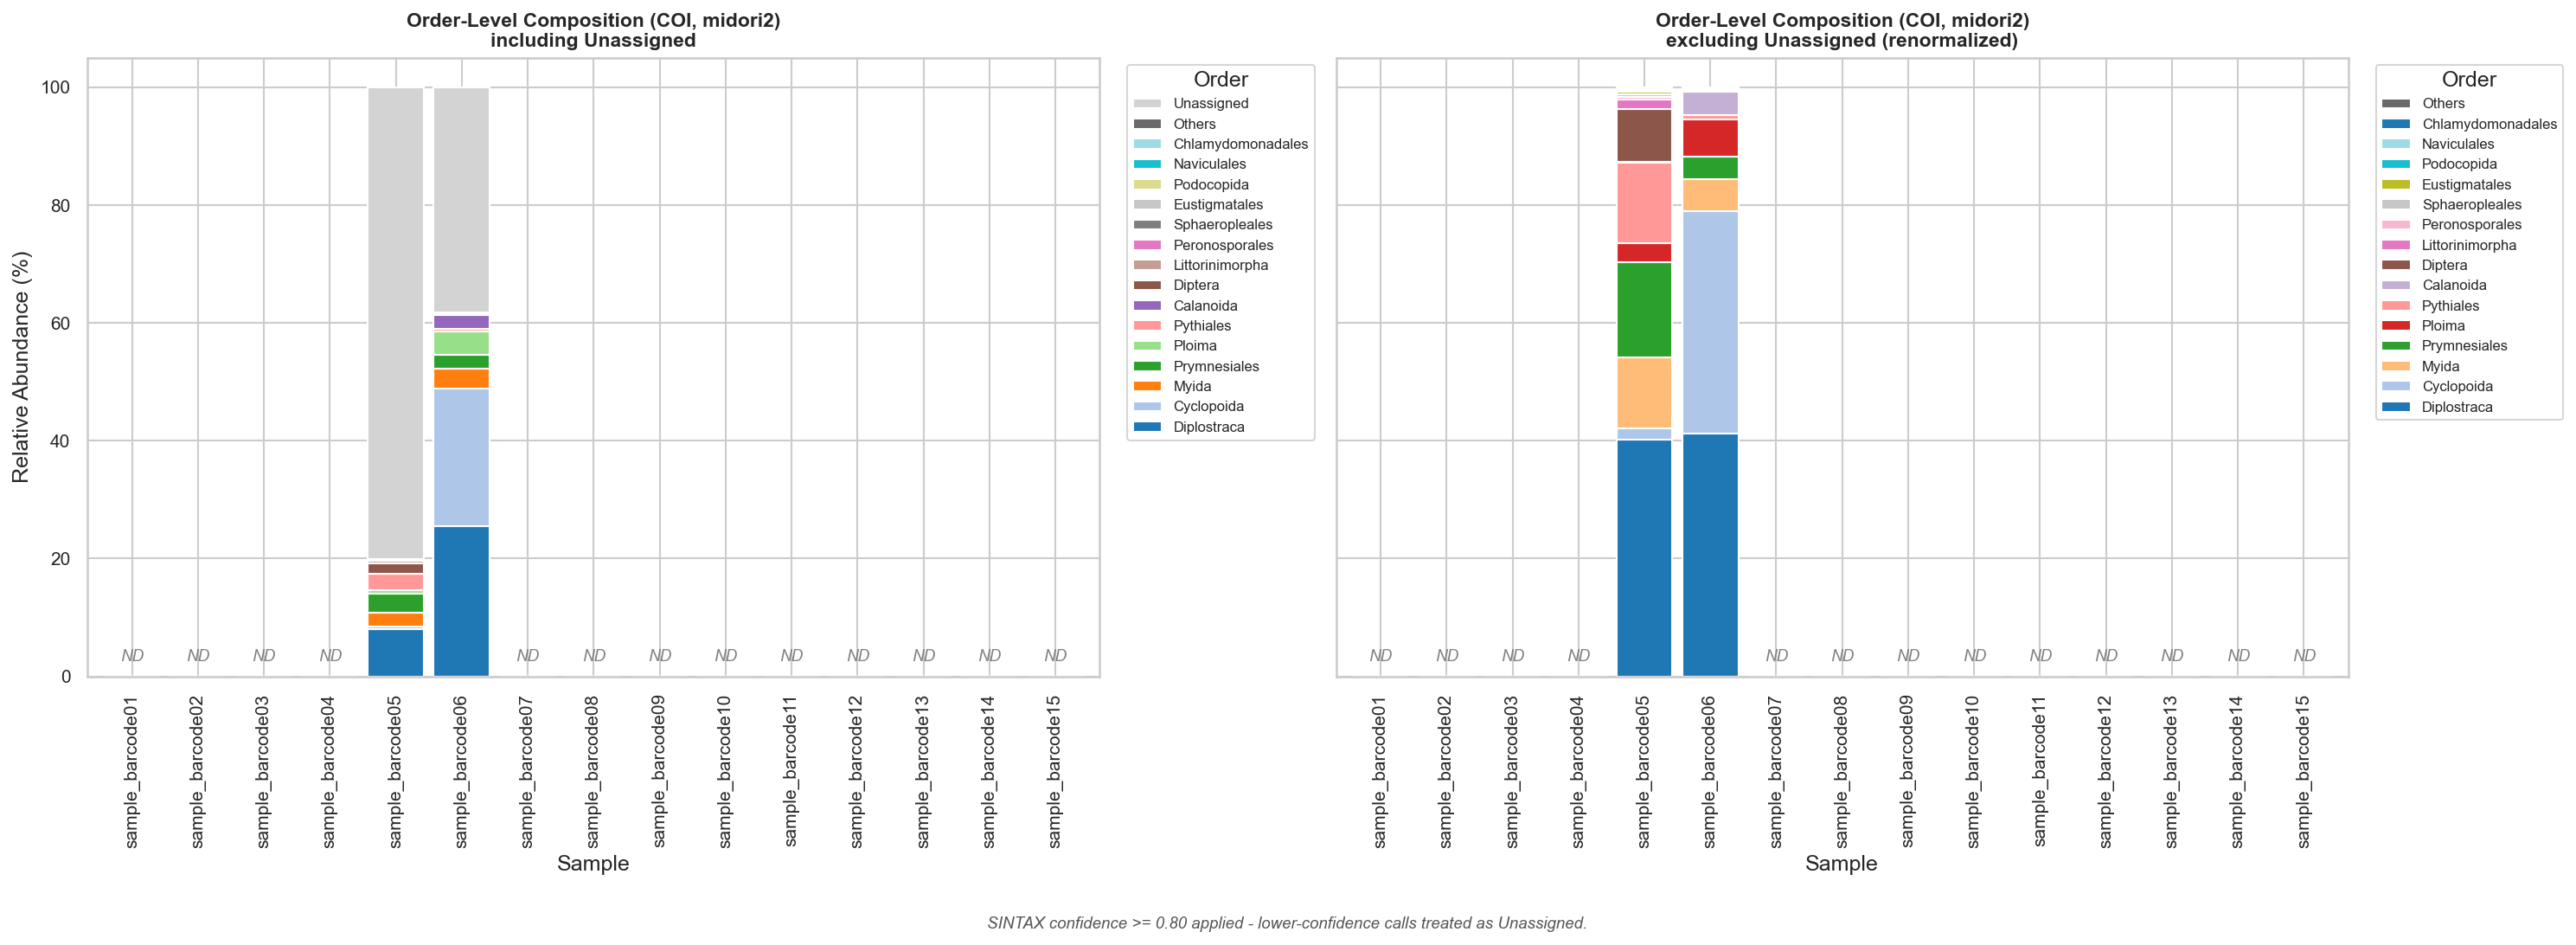

In [21]:
stacked_bar_compare(df_coi, 'Order', prefix_coi, 'COI', sample_cols_coi, top_n=15)

## B.3 Genus-Level Top 20 (COI)
Top genera with high confidence.

\\wsl.localhost\Ubuntu\home\ilias\Geno\Leman-eDNA-Pipeline\scripts\notebook_utils.py:688: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top['Total'], y=top.index, palette='viridis', ax=ax)


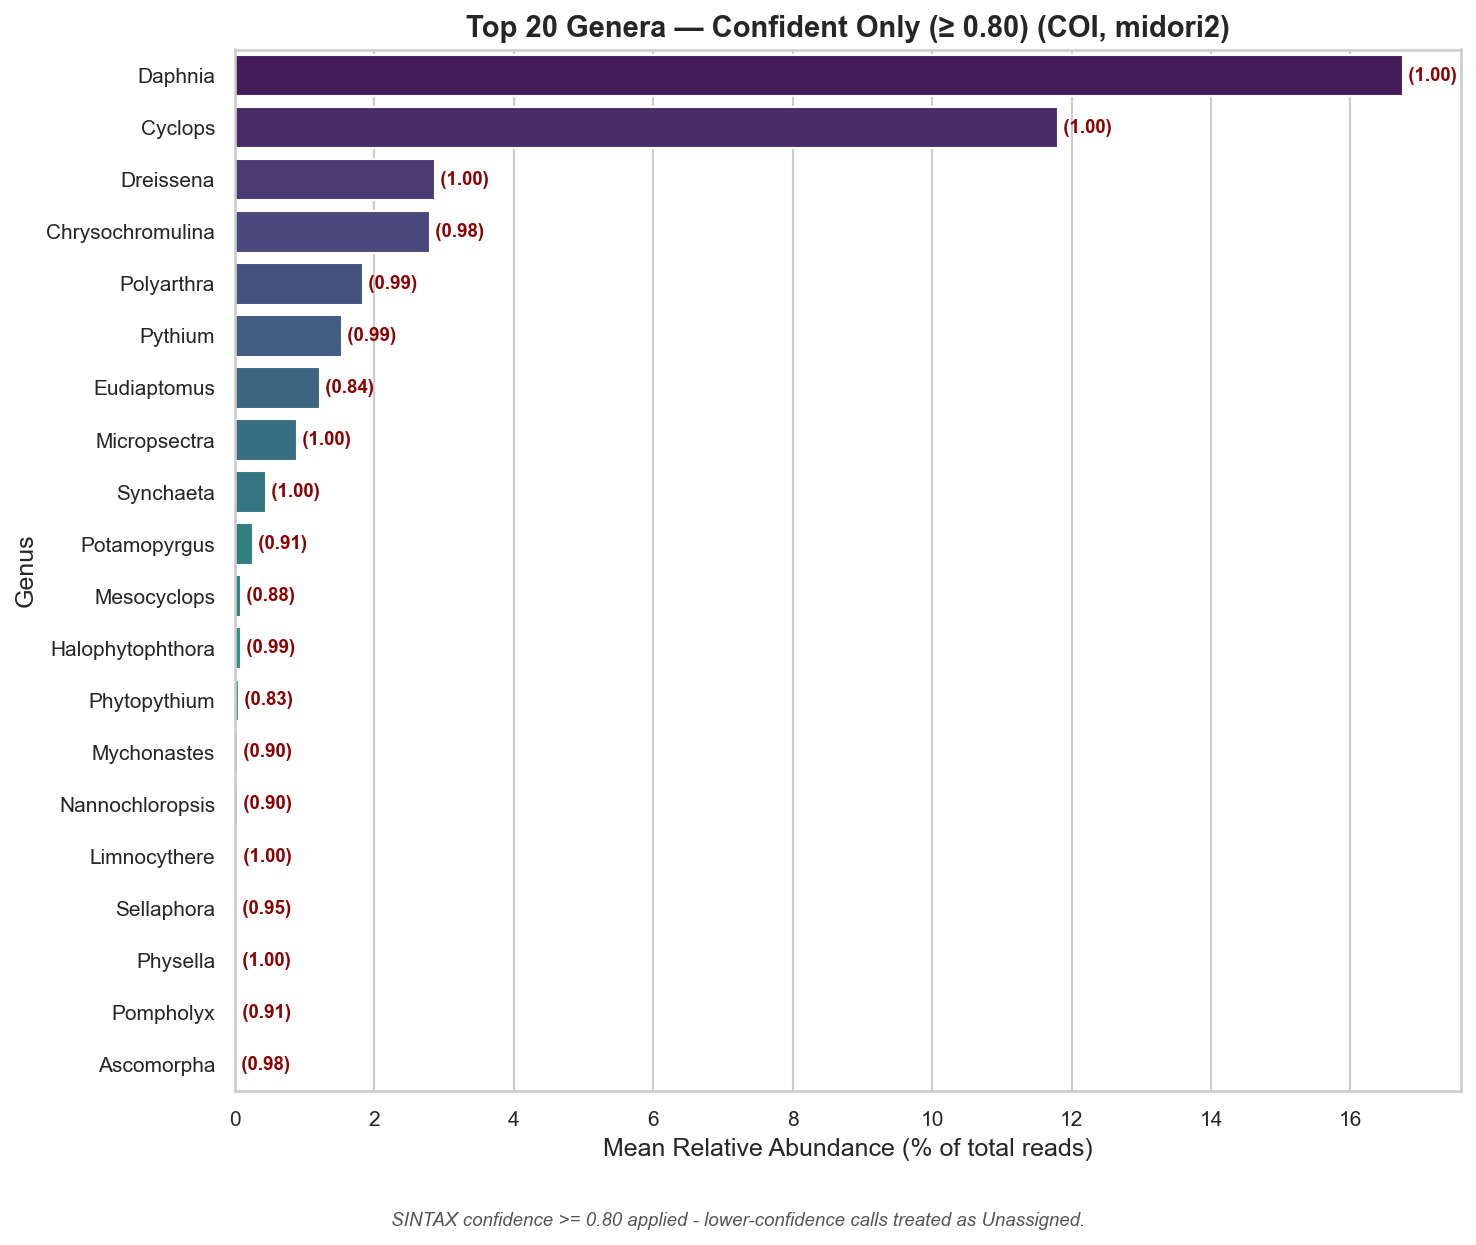

In [22]:
plot_top_genera_confident(df_coi, prefix_coi, 'COI', sample_cols_coi)

### Top 20 Genera by Abundance — All Confidences (COI)
All genus assignments ranked by abundance.

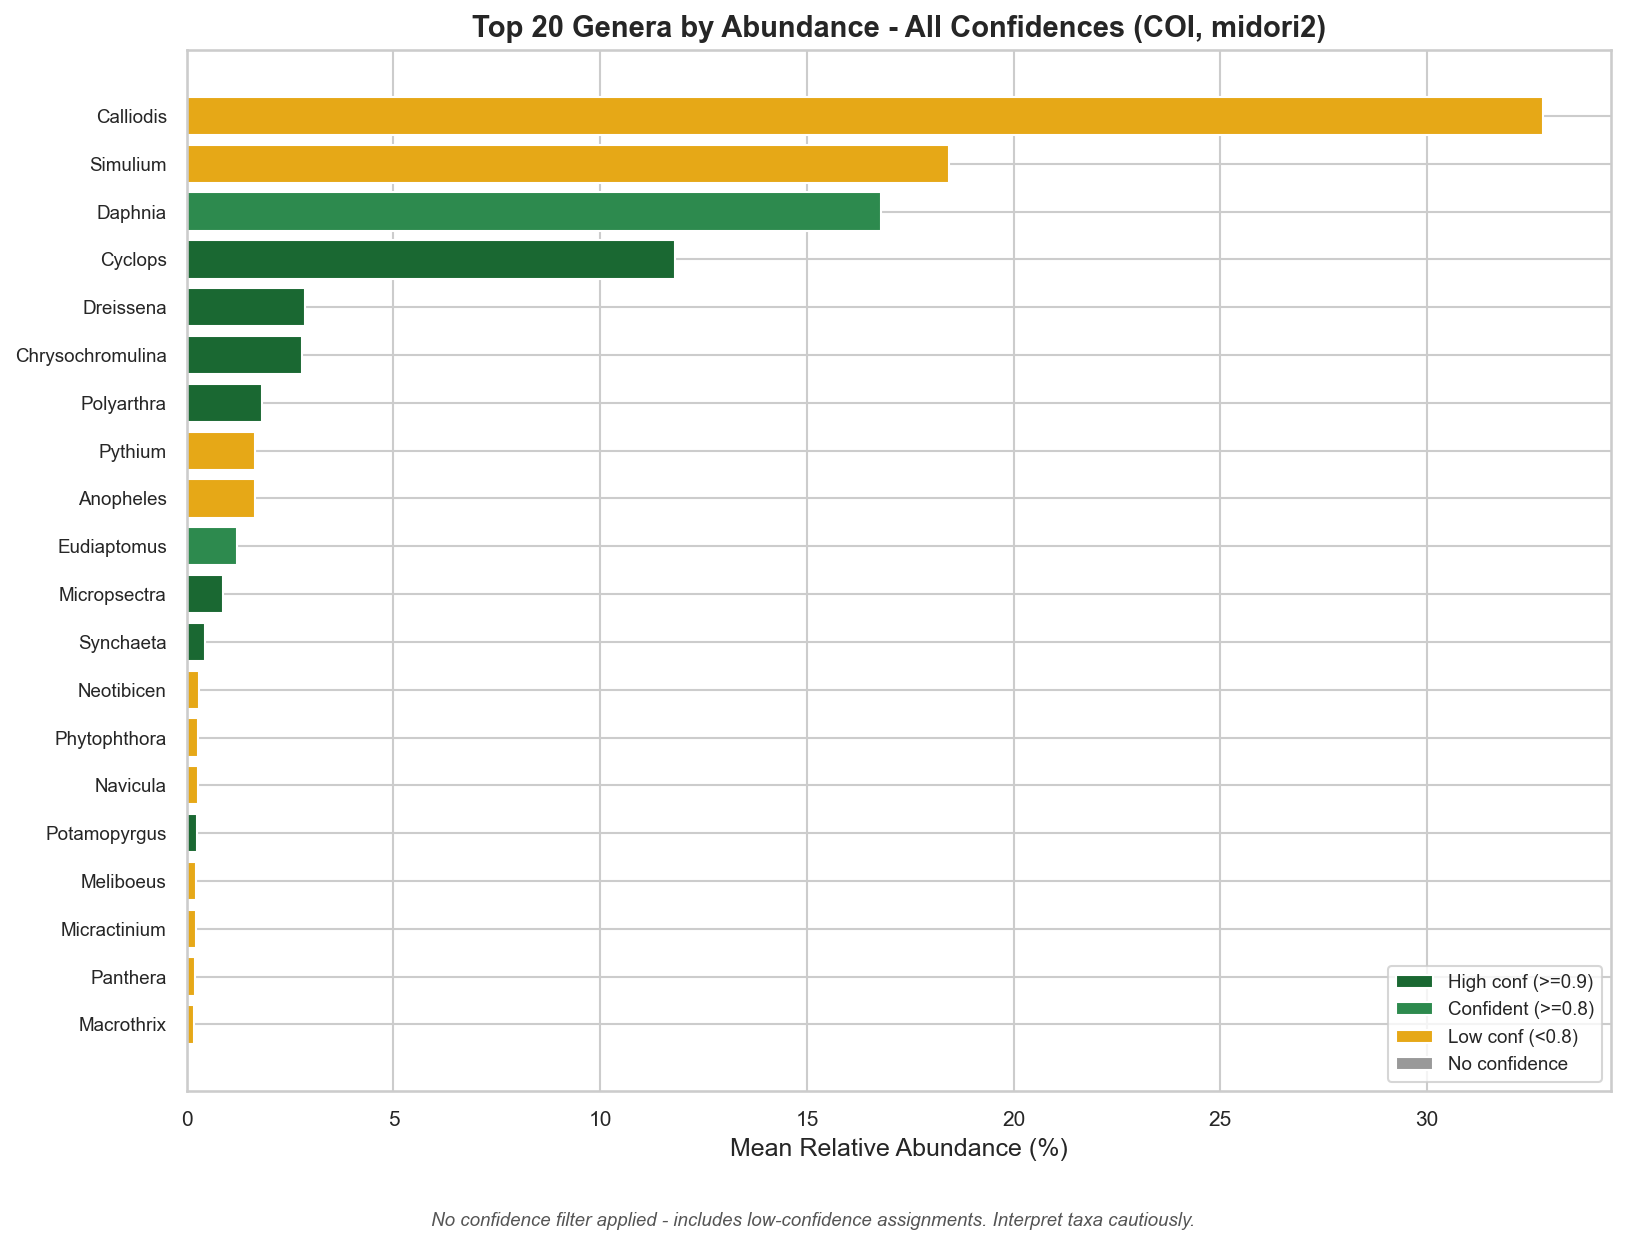

In [23]:
plot_top_genera_all(df_coi, prefix_coi, 'COI', sample_cols_coi)

## B.3b Top 20 Eukaryotic Genera (COI, MIDORI2)
Filtered to Eukaryota only with confidence >= 0.8.

No Domain column found (midori2_domain), using all OTUs


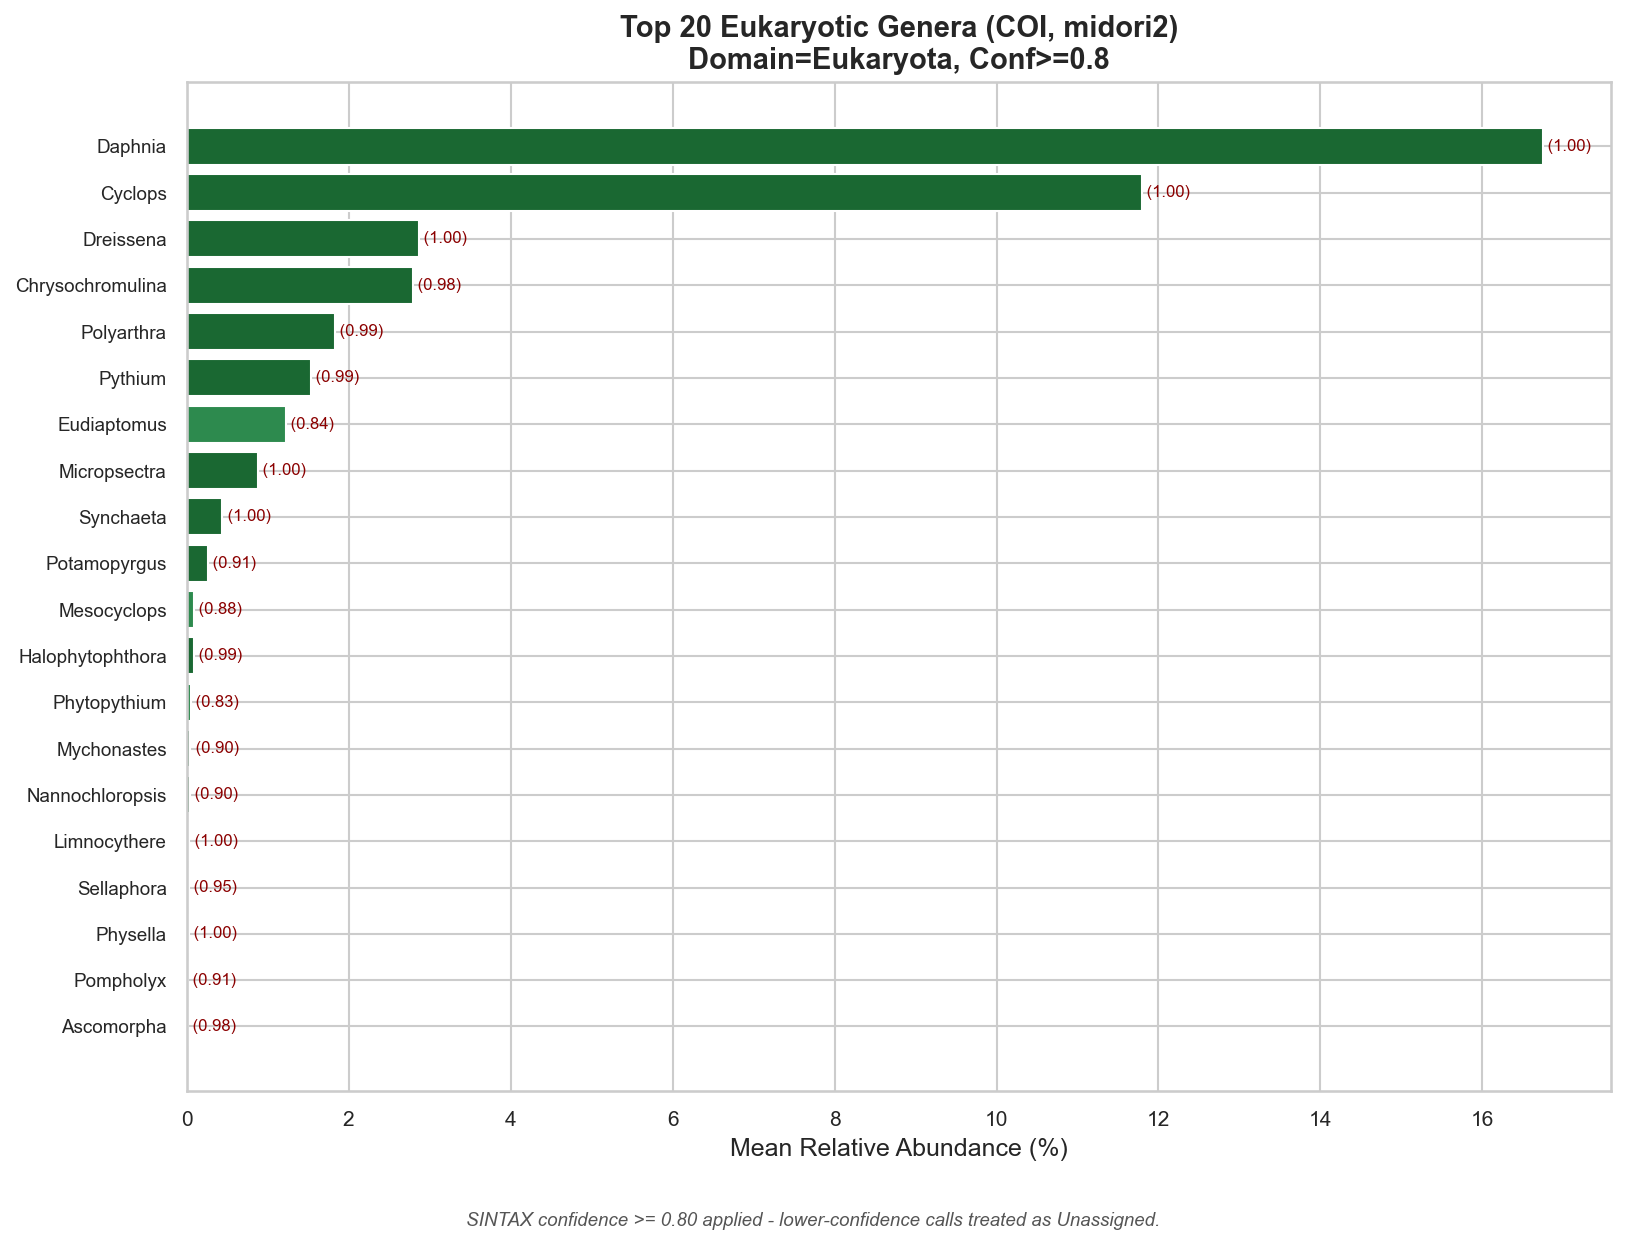

In [24]:
plot_eukaryotic_genera(df_coi, prefix_coi, 'COI', sample_cols_coi)

## BLAST Validation — COI
Top COI OTUs validated against NCBI GenBank.

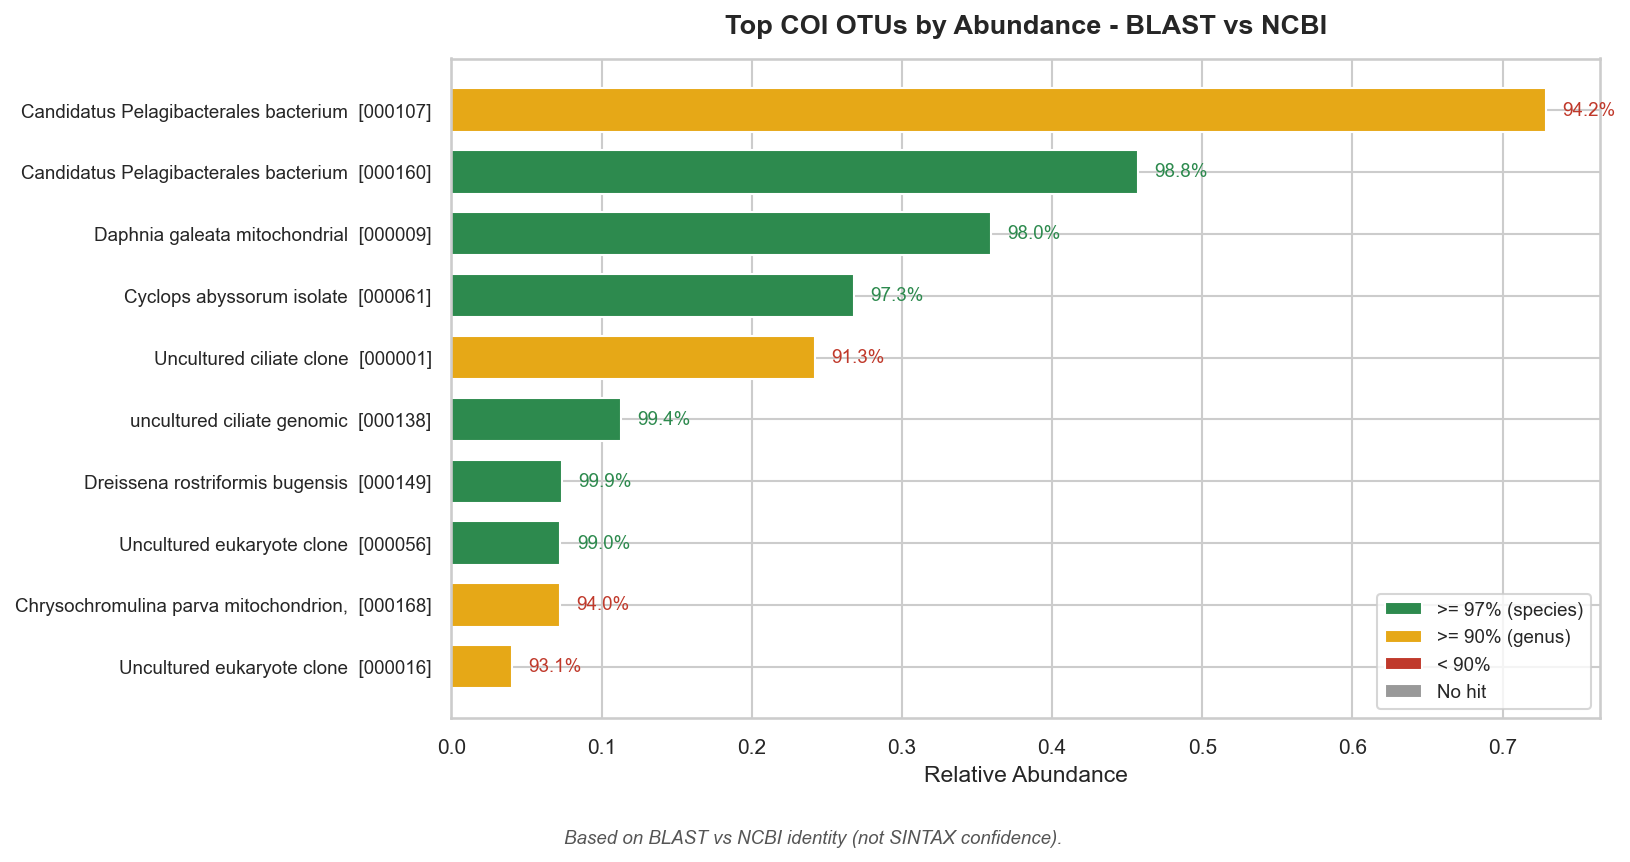

\\wsl.localhost\Ubuntu\home\ilias\Geno\Leman-eDNA-Pipeline\scripts\notebook_utils.py:945: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  .applymap(color_id, subset=['Identity (%)'])


OTU,Abundance,BLAST Top Hit,Identity (%),kingdom,phylum,class,order,family,genus,species
OTU_COI_000107,0.7287,Candidatus Pelagibacterales bacterium,94.2%,Eukaryota (1.00),Arthropoda (0.36),Insecta (0.30),Hemiptera (0.07),Anthocoridae (0.01),Calliodis (0.01),Calliodis (0.01)
OTU_COI_000160,0.4574,Candidatus Pelagibacterales bacterium,98.8%,Eukaryota (1.00),Arthropoda (0.20),Insecta (0.15),Diptera (0.04),Simuliidae (0.02),Simulium (0.02),Simulium (0.02)
OTU_COI_000009,0.3592,Daphnia galeata mitochondrial,98.0%,Eukaryota (1.00),Arthropoda (1.00),Branchiopoda (1.00),Diplostraca (1.00),Daphniidae (1.00),Daphnia (1.00),Daphnia (1.00)
OTU_COI_000061,0.2683,Cyclops abyssorum isolate,97.3%,Eukaryota (1.00),Arthropoda (1.00),Hexanauplia (1.00),Cyclopoida (1.00),Cyclopidae (1.00),Cyclops (1.00),Cyclops (1.00)
OTU_COI_000001,0.2421,Uncultured ciliate clone,91.3%,Eukaryota (1.00),Arthropoda (0.41),Insecta (0.26),Coleoptera (0.09),Cerambycidae (0.02),Pseudoplites (0.01),Pseudoplites (0.01)
OTU_COI_000138,0.1129,uncultured ciliate genomic,99.4%,Eukaryota (1.00),Arthropoda (0.37),Insecta (0.28),Coleoptera (0.12),Silphidae (0.02),Calosilpha (0.01),Calosilpha (0.01)
OTU_COI_000149,0.0735,Dreissena rostriformis bugensis,99.9%,Eukaryota (1.00),Mollusca (1.00),Bivalvia (1.00),Myida (1.00),Dreissenidae (1.00),Dreissena (1.00),Dreissena (1.00)
OTU_COI_000056,0.0726,Uncultured eukaryote clone,99.0%,Eukaryota (1.00),Arthropoda (0.36),Insecta (0.26),Diptera (0.06),Culicidae (0.02),Anopheles (0.01),Anopheles (0.01)
OTU_COI_000168,0.0720,"Chrysochromulina parva mitochondrion,",94.0%,Eukaryota (1.00),Haptophyta (0.98),–,Prymnesiales (0.98),Chrysochromulinaceae (0.98),Chrysochromulina (0.98),Chrysochromulina (0.98)
OTU_COI_000016,0.0403,Uncultured eukaryote clone,93.1%,Eukaryota (1.00),Arthropoda (0.39),Insecta (0.33),Coleoptera (0.09),Lampyridae (0.02),Trisinuata (0.01),Trisinuata (0.01)


In [25]:
plot_blast_hits(str(BASE / 'blast_results/blast_top10_abundance_COI.txt'), 'COI', 'Abundance')
blast_vs_sintax_table(str(BASE / 'blast_results/blast_top10_abundance_COI.txt'), df_coi_raw, prefix_coi, 'COI')

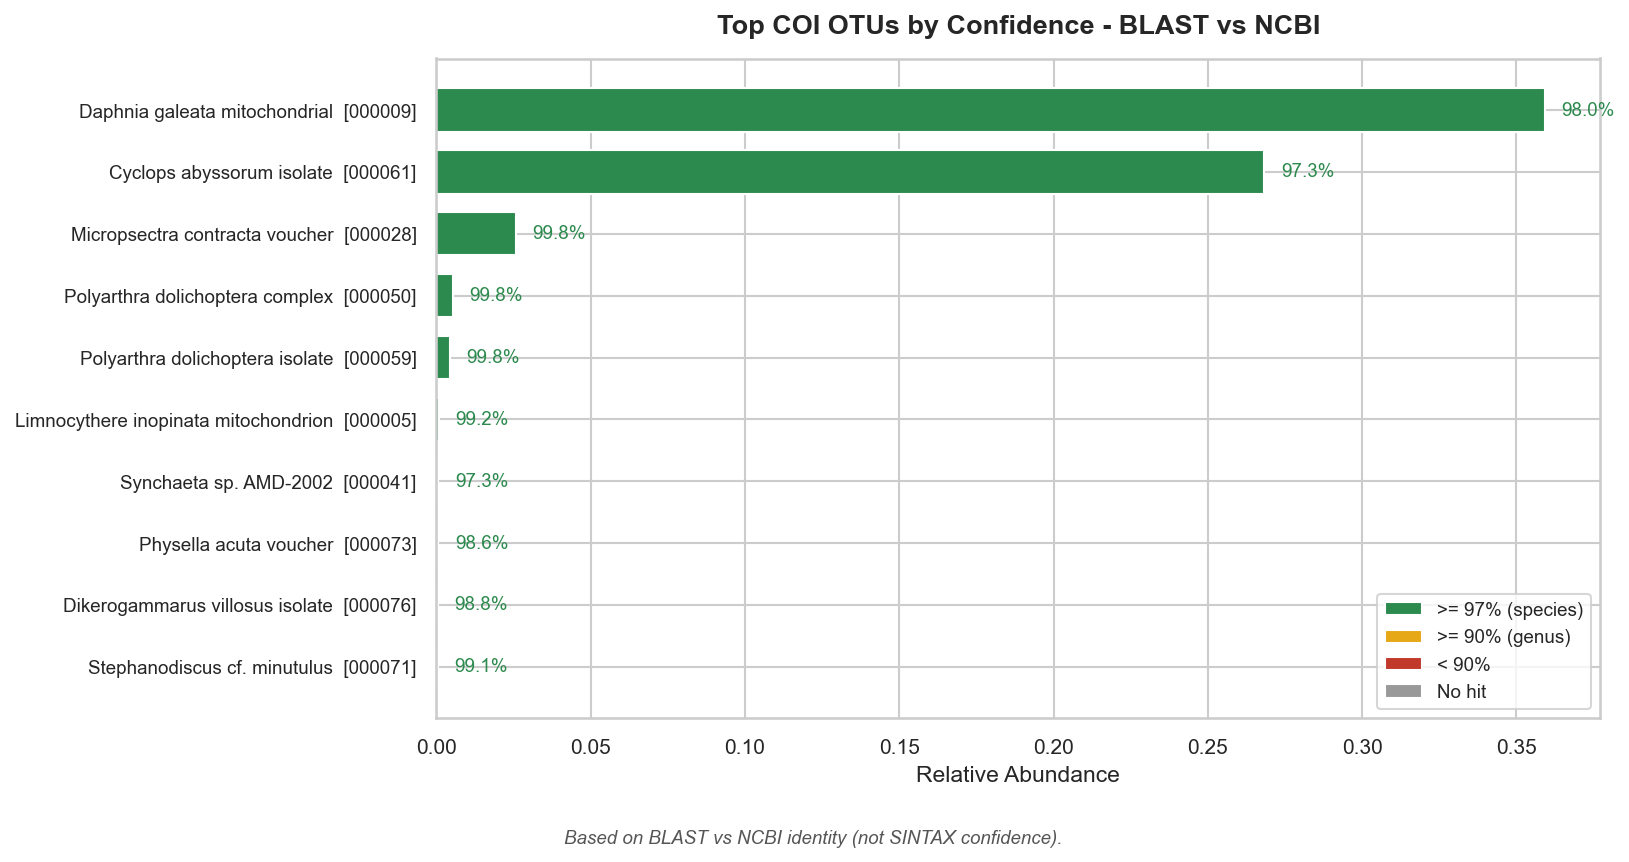

\\wsl.localhost\Ubuntu\home\ilias\Geno\Leman-eDNA-Pipeline\scripts\notebook_utils.py:945: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  .applymap(color_id, subset=['Identity (%)'])


OTU,Abundance,BLAST Top Hit,Identity (%),kingdom,phylum,class,order,family,genus,species
OTU_COI_000005,0.0007,Limnocythere inopinata mitochondrion,99.2%,Eukaryota (1.00),Arthropoda (1.00),Ostracoda (1.00),Podocopida (1.00),Limnocytheridae (1.00),Limnocythere (1.00),Limnocythere (1.00)
OTU_COI_000009,0.3592,Daphnia galeata mitochondrial,98.0%,Eukaryota (1.00),Arthropoda (1.00),Branchiopoda (1.00),Diplostraca (1.00),Daphniidae (1.00),Daphnia (1.00),Daphnia (1.00)
OTU_COI_000061,0.2683,Cyclops abyssorum isolate,97.3%,Eukaryota (1.00),Arthropoda (1.00),Hexanauplia (1.00),Cyclopoida (1.00),Cyclopidae (1.00),Cyclops (1.00),Cyclops (1.00)
OTU_COI_000050,0.0054,Polyarthra dolichoptera complex,99.8%,Eukaryota (1.00),Rotifera (1.00),Eurotatoria (1.00),Ploima (1.00),Synchaetidae (1.00),Polyarthra (1.00),Polyarthra (1.00)
OTU_COI_000059,0.0043,Polyarthra dolichoptera isolate,99.8%,Eukaryota (1.00),Rotifera (1.00),Eurotatoria (1.00),Ploima (1.00),Synchaetidae (1.00),Polyarthra (1.00),Polyarthra (1.00)
OTU_COI_000041,0.0006,Synchaeta sp. AMD-2002,97.3%,Eukaryota (1.00),Rotifera (1.00),Eurotatoria (1.00),Ploima (1.00),Synchaetidae (1.00),Synchaeta (1.00),Synchaeta (1.00)
OTU_COI_000028,0.0258,Micropsectra contracta voucher,99.8%,Eukaryota (1.00),Arthropoda (1.00),Insecta (1.00),Diptera (1.00),Chironomidae (1.00),Micropsectra (1.00),Micropsectra (1.00)
OTU_COI_000071,0.0004,Stephanodiscus cf. minutulus,99.1%,Eukaryota (1.00),Bacillariophyta (1.00),Coscinodiscophyceae (1.00),Stephanodiscales (1.00),Stephanodiscaceae (1.00),Stephanodiscus (1.00),Stephanodiscus (1.00)
OTU_COI_000073,0.0006,Physella acuta voucher,98.6%,Eukaryota (1.00),Mollusca (1.00),Gastropoda (1.00),–,Physidae (1.00),Physella (1.00),Physella (1.00)
OTU_COI_000076,0.0004,Dikerogammarus villosus isolate,98.8%,Eukaryota (1.00),Arthropoda (1.00),Malacostraca (1.00),Amphipoda (1.00),Gammaridae (1.00),Dikerogammarus (1.00),Dikerogammarus (1.00)


In [26]:
plot_blast_hits(str(BASE / 'blast_results/blast_top10_confidence_COI.txt'), 'COI', 'Confidence')
blast_vs_sintax_table(str(BASE / 'blast_results/blast_top10_confidence_COI.txt'), df_coi_raw, prefix_coi, 'COI')

## Cross-Marker Comparison (18S vs COI)
Genera detected by each marker — overlap reveals complementary coverage.

In [27]:
cross_marker_genus_comparison([
    (df_18s, prefix_18s, '18S'),
    (df_coi, prefix_coi, 'COI')
])

Genera detected by 18S (pr2): 25
Genera detected by COI (midori2): 22

Shared: 1
Only 18S: 24
Only COI: 21

Shared genera: ['Dikerogammarus']
